# Initialization

In [1]:
# ---- Patch 0: safer GPU config (run once, near the top) ----
import tensorflow as tf
tf.config.set_soft_device_placement(True)  # let TF fallback to CPU if needed

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found and memory growth enabled: {gpus}")
    except Exception as e:
        print("Could not enable memory growth:", e)
else:
    print("No GPU detected; running on CPU.")


2025-08-24 01:02:35.010241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-24 01:02:35.220703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755984755.296870    8649 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755984755.318215    8649 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755984755.485582    8649 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU(s) found and memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import glob
import numpy as np

npy_files = glob.glob('cached_np/*.npy')
data_arrays = {file.split('/')[-1].replace('.npy', ''): np.load(file) for file in npy_files}

print(f"Loaded {len(data_arrays)} variables from .npy files.")


Loaded 7 variables from .npy files.


# Preprocessing

In [3]:
vars_to_check = [
    'X_all',
    'Y_all',
    'wrench_all',
    'Z_all',
    'angles_all',
    'wrench_out_all',
    'currents_all'
]

for name in vars_to_check:
    if name in data_arrays:
        arr = np.array(data_arrays[name])
        print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
              f"min={np.nanmin(arr):.6f}, max={np.nanmax(arr):.6f}, "
              f"NaNs={np.isnan(arr).sum()}")
    else:
        print(f"{name}: NOT FOUND in data_arrays")


X_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
Y_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
wrench_all: shape=(6, 1411344), dtype=float64, min=-71.323061, max=67.910946, NaNs=0
Z_all: shape=(1, 1411344), dtype=float64, min=0.005000, max=0.005000, NaNs=0
angles_all: shape=(3, 1411344), dtype=float64, min=-3.141593, max=3.141593, NaNs=0
wrench_out_all: shape=(6, 1411344), dtype=float64, min=-43712933.130251, max=36944979.677285, NaNs=0
currents_all: shape=(16, 1411344), dtype=float64, min=-5885.689556, max=16889.743946, NaNs=0


In [4]:
# Build ARR as [N,16] from whatever you loaded. Then re-run the previous analysis cell.

import numpy as np

def find_currents_matrix(dct):
    # 2D with 16 cols
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[1] == 16:
            return a
    # 2D with 16 rows -> transpose
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[0] == 16:
            return a.T
    # 1D or weird -> reshape by 16
    for v in dct.values():
        a = np.array(v).ravel()
        if a.size % 16 == 0 and a.size >= 16:
            return a.reshape(-1, 16)
    raise ValueError("No 16-current structure found in data_arrays.")

ARR = find_currents_matrix(data_arrays)
print("ARR shape:", ARR.shape)

ARR shape: (1411344, 16)


In [5]:
# Ensure shape is [N_samples, N_channels]
W = np.array(data_arrays['wrench_out_all'], dtype=float)
if W.shape[0] < W.shape[1]:
    W = W.T  # transpose to get samples as rows

print("Fixed wrench_out_all shape:", W.shape)  # should be (1895400, 6)

Fixed wrench_out_all shape: (1411344, 6)


In [6]:
import numpy as np

# Preprocess into sample-aligned arrays

def to_samples_first(arr):
    arr = np.array(arr, dtype=float)
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr

# Flatten small coordinate arrays
def flatten_coord(arr):
    return np.array(arr, dtype=float).ravel()

X_all = flatten_coord(data_arrays['X_all'])
Y_all = flatten_coord(data_arrays['Y_all'])
Z_all = flatten_coord(data_arrays['Z_all'])
angles_all = np.array(data_arrays['angles_all'], dtype=float)
if angles_all.shape[0] < angles_all.shape[1]:
    angles_all = angles_all.T  # now shape [N, 3]

wrench_all = to_samples_first(data_arrays['wrench_all'])          # [N, 6]
wrench_out_all = to_samples_first(data_arrays['wrench_out_all'])  # [N, 6]
currents_all = to_samples_first(data_arrays['currents_all'])      # [N, 16]

# Sanity check: all sample counts
N_samples = max(len(X_all), wrench_all.shape[0], currents_all.shape[0])
print("Sample counts:")
print(f"X_all:           {X_all.shape}")
print(f"Y_all:           {Y_all.shape}")
print(f"Z_all:           {Z_all.shape}")
print(f"angles_all:      {angles_all.shape}")
print(f"wrench_all:      {wrench_all.shape}")
print(f"wrench_out_all:  {wrench_out_all.shape}")
print(f"currents_all:    {currents_all.shape}")

# Verify alignment
if not (len(X_all) == len(Y_all) == len(Z_all) == angles_all.shape[0] == wrench_all.shape[0] == wrench_out_all.shape[0] == currents_all.shape[0]):
    print("WARNING: Arrays differ in length, need resampling or trimming.")
else:
    print("All arrays aligned to", N_samples, "samples.")


Sample counts:
X_all:           (1411344,)
Y_all:           (1411344,)
Z_all:           (1411344,)
angles_all:      (1411344, 3)
wrench_all:      (1411344, 6)
wrench_out_all:  (1411344, 6)
currents_all:    (1411344, 16)
All arrays aligned to 1411344 samples.


## Creating the Dataframe

In [7]:
import numpy as np
import pandas as pd


# Build dataframe
df = pd.DataFrame()

# Y, Z from data
df['X'] = X_all
df['Y'] = Y_all
df['Z'] = Z_all

# Angles
for i in range(angles_all.shape[1]):
    df[f'angle_{i+1}'] = angles_all[:, i]

# Wrench (input)
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_{name}'] = wrench_all[:, i]

# Wrench out
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_out_{name}'] = wrench_out_all[:, i]

# Currents
for i in range(currents_all.shape[1]):
    df[f'current_{i+1}'] = currents_all[:, i]

print("Final dataset shape:", df.shape)
print(df.head(10))


Final dataset shape: (1411344, 34)
          X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  wrench_Fy  \
0 -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
1 -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
2 -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
3 -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
4 -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
5 -0.103125 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
6 -0.093750 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
7 -0.084375 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
8 -0.075000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
9 -0.065625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   

   wrench_Fz  wrench_Tx  ...  current_7  current_8  current_9  current_10  \
0      

# Data Analysis

## Wrench Investigation

In [8]:
# Run full analysis for wrench_out_all (reuses same plotting style)

FS = None  # set if you know sampling rate
cols = W.shape[1]

# Channel names guess
if cols == 6:
    CH = ["Fx","Fy","Fz","Tx","Ty","Tz"]
elif cols == 12:
    CH = [f"F{i}" for i in range(1,7)] + [f"T{i}" for i in range(1,7)]
else:
    CH = [f"C{i:02d}" for i in range(1, cols+1)]

UNITS = ""          # leave blank if mixed units
SAVE_DIR = "analysis_plots_wrench"
CLIP_QUANTILES = (0.001, 0.999)
SMOOTH_WINDOW = 0

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

X = np.array(W, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0])/float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# Summary
summary = pd.DataFrame({
    "channel": CH,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
})
print("Wrench summary:")
print(summary.round(6))




Wrench summary:
  channel        min        p01       p25    median      mean        p75  \
0      Fx -71.762163 -35.896928 -7.649506 -0.000000 -2.004577   1.960230   
1      Fy -71.762163 -30.437419 -3.339252  0.022254  2.602734   8.828112   
2      Fz -71.762163 -68.943046 -2.149142  0.553492  6.656157  17.823183   
3      Tx -71.762163 -14.189055 -2.521515 -0.000000 -0.551370   1.014062   
4      Ty -66.109715 -13.550148 -0.965381  0.000000  0.083460   1.450946   
5      Tz -71.762163 -10.271214 -0.110946  0.341150  1.190018   2.892426   

         p99        max        std      skew       kurt  
0  28.626263  72.990359  13.312557 -0.141276   2.333586  
1  41.769258  72.990359  14.248236  0.500969   2.029865  
2  68.505280  72.990359  30.118061 -0.020711   0.486861  
3  13.673413  72.990359   4.541524 -0.022875   7.745742  
4  13.975309  72.990359   4.276740  0.062824  11.279306  
5  12.477598  72.990359   3.992579  0.552637  44.553678  


## Currents Investigation

### Statistical plots of the currents in the dataset

In [9]:
# Use existing ARR = [N,16] to run full analysis

# === CONFIG ===
FS = None          # sampling rate in Hz (None => x-axis in samples)
CHANNEL_NAMES = [f"I{i:02d}" for i in range(1,17)]
UNITS = "A"
CLIP_QUANTILES = (0.001, 0.999)  # None to disable
SMOOTH_WINDOW = 0                # 0/None to disable
SAVE_DIR = "analysis_plots"
# ==============

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

assert ARR.ndim == 2 and ARR.shape[1] == 16, "ARR must be [N,16]"

# --- Preprocess ---
X = np.array(ARR, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0]) / float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# --- Summary stats ---
summary = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
})
print("Summary:")
print(summary.round(6))




Summary:
   channel   min   p01        p25  median      mean        p75   p99   max  \
0      I01 -10.0 -10.0  -9.999998     0.0 -0.014177   9.999997  10.0  10.0   
1      I02 -10.0 -10.0 -10.000000     0.0 -0.009607  10.000000  10.0  10.0   
2      I03 -10.0 -10.0 -10.000000     0.0 -0.007018  10.000000  10.0  10.0   
3      I04 -10.0 -10.0  -9.999947     0.0 -0.004106   9.999942  10.0  10.0   
4      I05 -10.0 -10.0 -10.000000     0.0 -0.001412  10.000000  10.0  10.0   
5      I06 -10.0 -10.0 -10.000000     0.0  0.006206  10.000000  10.0  10.0   
6      I07 -10.0 -10.0 -10.000000     0.0  0.005911  10.000000  10.0  10.0   
7      I08 -10.0 -10.0  -9.676148     0.0 -0.003654   9.650259  10.0  10.0   
8      I09 -10.0 -10.0  -8.193575     0.0 -0.001812   8.162526  10.0  10.0   
9      I10 -10.0 -10.0  -8.487969     0.0  0.006065   8.543623  10.0  10.0   
10     I11 -10.0 -10.0  -6.750586     0.0  0.005555   6.812999  10.0  10.0   
11     I12 -10.0 -10.0  -5.005669     0.0 -0.003962   4

### Currents values over the plane at fixed orientation and input

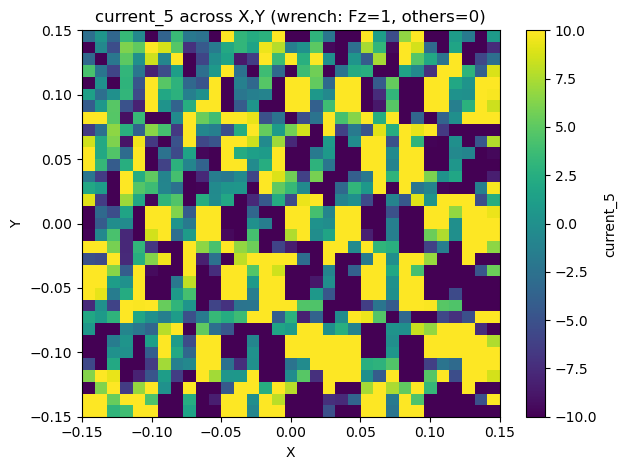

In [10]:
# filter to the fixed input wrench: Fx=Fy=Tx=Ty=Tz=0, Fz=1
w_cols = ['wrench_Fx','wrench_Fy','wrench_Fz','wrench_Tx','wrench_Ty','wrench_Tz']
df_ = df[(df['wrench_Fx']==1)&(df['wrench_Fy']==0)&(df['wrench_Fz']==0)&
         (df['wrench_Tx']==0)&(df['wrench_Ty']==0)&(df['wrench_Tz']==0)].copy()

# drop/ignore wrench_out*
df_ = df_.drop(columns=[c for c in df_.columns if c.startswith('wrench_out_')], errors='ignore')

# keep other things fixed: pick one unique value for every non-(X,Y,current_*,wrench_*) column
fixed_candidates = [
    c for c in df_.columns
    if c not in ['X','Y','current_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_candidates:
    vals = df_[c].dropna().unique()
    if len(vals) > 0:
        df_ = df_[df_[c] == vals[0]]

# make a grid of current_1 over X,Y
grid = df_.pivot_table(index='Y', columns='X', values='current_16', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='current_5')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('current_5 across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()


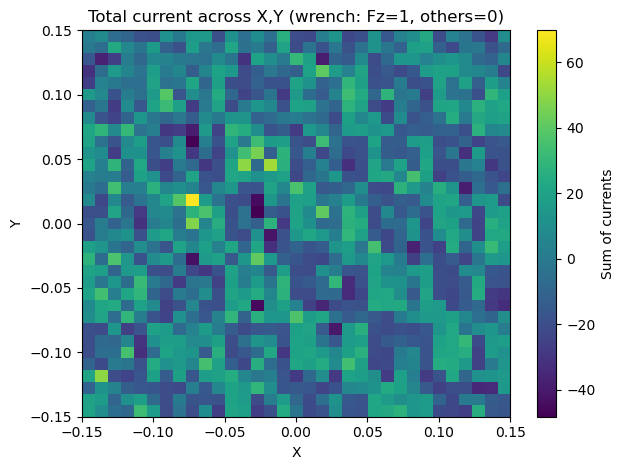

In [11]:
# sum all currents
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)

# make grid over X,Y for the sum
grid = df_.pivot_table(index='Y', columns='X', values='current_sum', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='Sum of currents')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Total current across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()

### Currents dependancy on angles analysis

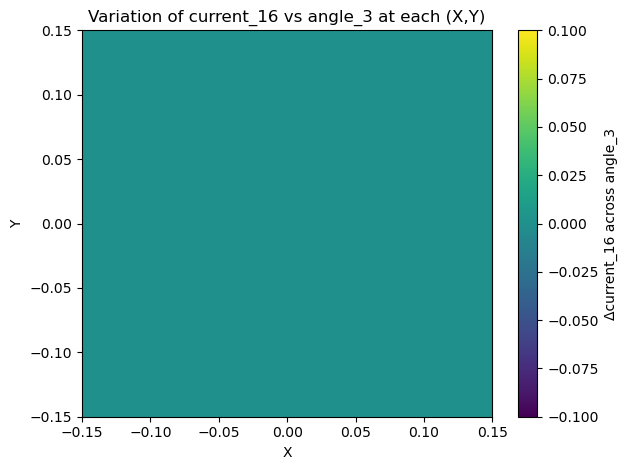

In [12]:
# keep angle_3 free; fix everything else (angles 1&2 fixed)
fixed_cols = [
    c for c in df_.columns
    if c not in ['X','Y','angle_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_cols:
    vals = df_[c].dropna().unique()
    if len(vals): df_ = df_[df_[c] == vals[0]]

# ---- choose what to measure ----
# (A) total current variation across angle_3
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)
target = 'current_sum'

# # (B) single coil instead (uncomment to use)
target = 'current_16'

# range (max - min) over angle_3 at each (X,Y)
delta_xy = (df_.groupby(['X','Y'])[target]
              .agg(lambda s: s.max() - s.min())
              .reset_index(name='delta'))

# heatmap
grid = delta_xy.pivot(index='Y', columns='X', values='delta').sort_index().sort_index(axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label=f'Δ{target} across angle_3')
plt.xlabel('X'); plt.ylabel('Y')
plt.title(f'Variation of {target} vs angle_3 at each (X,Y)')
plt.tight_layout()


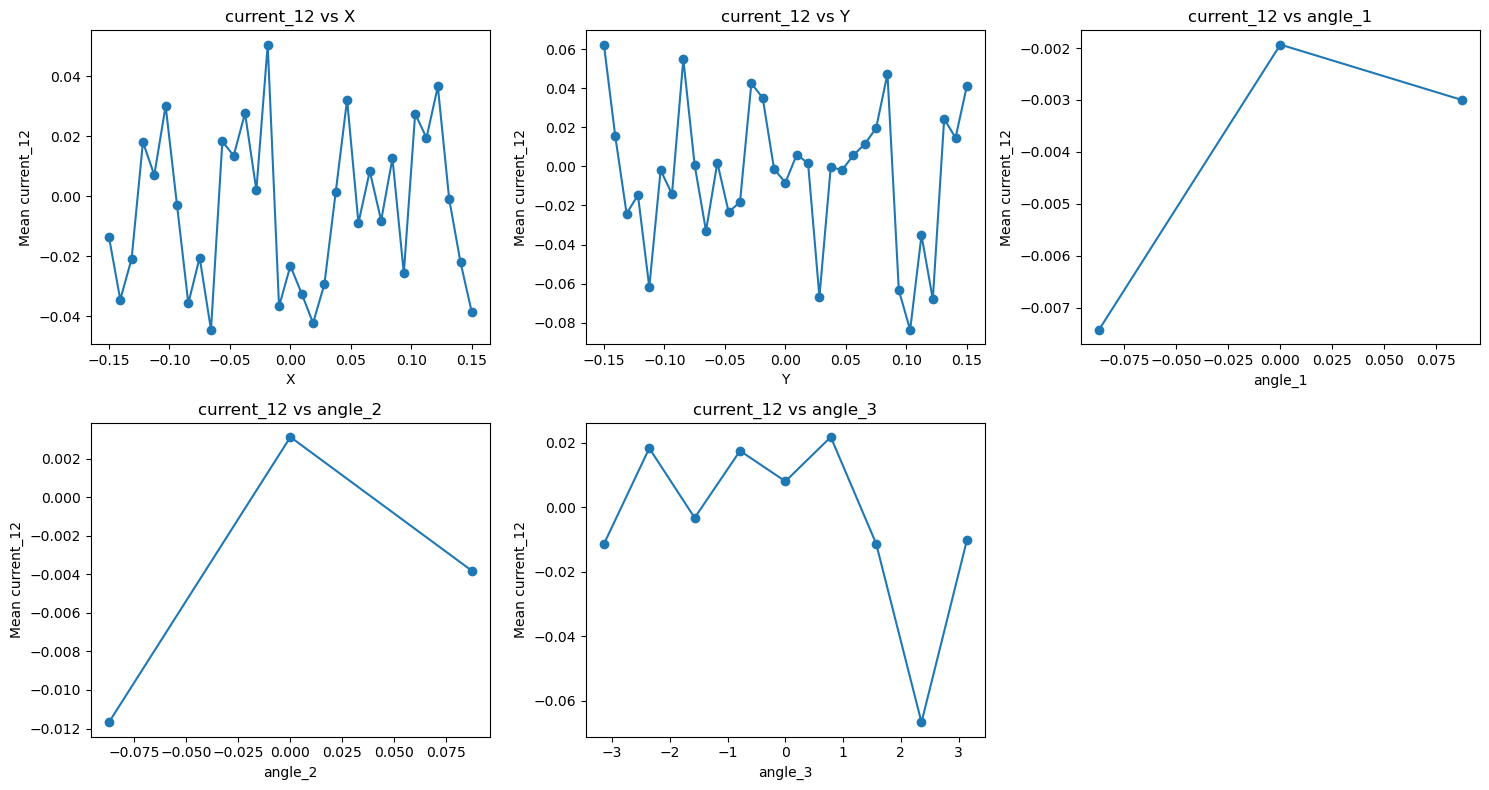

In [13]:
import matplotlib.pyplot as plt

target = 'current_12'  # change to current_5 or others if you want

vars_to_check = ['X', 'Y', 'angle_1', 'angle_2', 'angle_3']

plt.figure(figsize=(15, 8))

for i, var in enumerate(vars_to_check, 1):
    mean_vals = df.groupby(var)[target].mean().reset_index()
    plt.subplot(2, 3, i)
    plt.plot(mean_vals[var], mean_vals[target], marker='o')
    plt.xlabel(var)
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} vs {var}")

plt.tight_layout()
plt.show()


### Current values over dataset samples

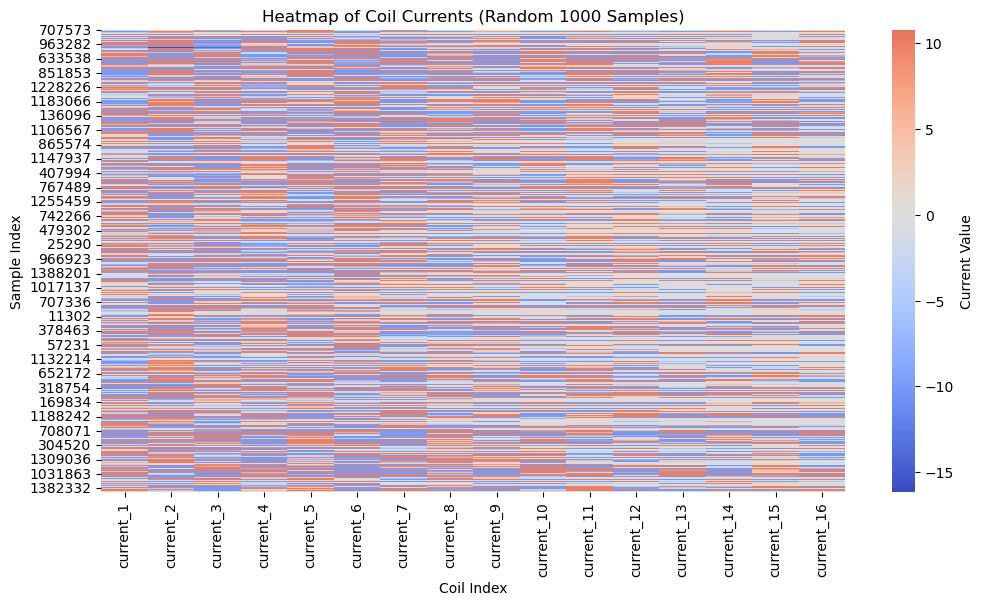

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick 1000 random samples
curr_cols = [c for c in df.columns if c.startswith('current_')]
rand_idx = np.random.choice(df.index, size=1000, replace=False)
currents_subset = df.loc[rand_idx, curr_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(currents_subset, cmap='coolwarm', center=0, cbar_kws={'label': 'Current Value'})
plt.xlabel('Coil Index')
plt.ylabel('Sample Index')
plt.title('Heatmap of Coil Currents (Random 1000 Samples)')
plt.show()


### Frequency Analysis of currents over X-Y Plane

Visualize for one coil as an example

Dominant spatial frequency vector: (9.6970, -9.6970)
Dominant wavelength: 0.0729 units
Orientation of bands: -45.00 degrees


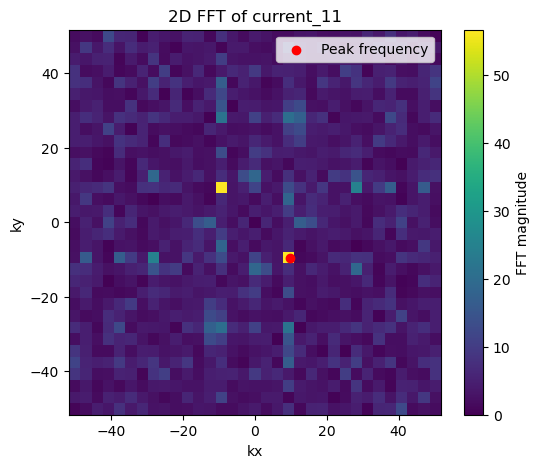

In [15]:
import numpy as np
import matplotlib.pyplot as plt

target = 'current_11'  # change if you want another coil

# Pivot into a 2D grid
grid = df.pivot_table(index='Y', columns='X', values=target, aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)  # sort axes

# Coordinates
X_coords = grid.columns.to_numpy()
Y_coords = grid.index.to_numpy()

# FFT
F = np.fft.fftshift(np.fft.fft2(grid.fillna(0).to_numpy()))
F_mag = np.abs(F)

# Find dominant frequency (ignore DC component)
center = tuple(np.array(F_mag.shape) // 2)
F_mag[center] = 0
peak_idx = np.unravel_index(np.argmax(F_mag), F_mag.shape)

# Frequency steps
dx = X_coords[1] - X_coords[0]
dy = Y_coords[1] - Y_coords[0]
kx = np.fft.fftshift(np.fft.fftfreq(len(X_coords), d=dx))
ky = np.fft.fftshift(np.fft.fftfreq(len(Y_coords), d=dy))

peak_kx = kx[peak_idx[1]]
peak_ky = ky[peak_idx[0]]

# Wavelength & orientation
wavelength = 1 / np.sqrt(peak_kx**2 + peak_ky**2)
orientation_deg = np.degrees(np.arctan2(peak_ky, peak_kx))

print(f"Dominant spatial frequency vector: ({peak_kx:.4f}, {peak_ky:.4f})")
print(f"Dominant wavelength: {wavelength:.4f} units")
print(f"Orientation of bands: {orientation_deg:.2f} degrees")

# Plot FFT magnitude
plt.figure(figsize=(6,5))
plt.imshow(F_mag, extent=[kx.min(), kx.max(), ky.min(), ky.max()], origin='lower', aspect='auto')
plt.colorbar(label='FFT magnitude')
plt.scatter([peak_kx], [peak_ky], color='red', label='Peak frequency')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title(f'2D FFT of {target}')
plt.legend()
plt.show()


The report of FFt for all coils

In [16]:
import numpy as np
import pandas as pd

def fft_xy_params_for_all_coils(df, current_prefix='current_'):
    results = []
    Xs = np.sort(df['X'].unique())
    Ys = np.sort(df['Y'].unique())
    dx = np.diff(Xs).mean()
    dy = np.diff(Ys).mean()
    kx = np.fft.fftshift(np.fft.fftfreq(len(Xs), d=dx))
    ky = np.fft.fftshift(np.fft.fftfreq(len(Ys), d=dy))

    for col in [c for c in df.columns if c.startswith(current_prefix)]:
        grid = (df.pivot_table(index='Y', columns='X', values=col, aggfunc='mean')
                  .reindex(index=Ys, columns=Xs))
        A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()

        F = np.fft.fftshift(np.fft.fft2(A))
        M = np.abs(F)
        cy, cx = np.array(M.shape)//2
        M[cy, cx] = 0  # drop DC
        py, px = np.unravel_index(np.argmax(M), M.shape)

        kx_peak = kx[px]
        ky_peak = ky[py]
        k_mag = np.hypot(kx_peak, ky_peak)
        wavelength = 1.0/k_mag if k_mag > 0 else np.nan

        k_angle_deg = np.degrees(np.arctan2(ky_peak, kx_peak))            # wavevector angle
        bands_angle_deg = (k_angle_deg + 90.0 + 180.0) % 180.0            # stripe orientation

        results.append({
            'coil': col,
            'kx': kx_peak,
            'ky': ky_peak,
            'k_mag': k_mag,
            'wavelength': wavelength,
            'k_angle_deg': k_angle_deg,
            'bands_angle_deg': bands_angle_deg
        })

    return pd.DataFrame(results).sort_values('coil').reset_index(drop=True)

# usage:
params_df = fft_xy_params_for_all_coils(df)
print(params_df)


/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or o

          coil         kx         ky      k_mag  wavelength  k_angle_deg  \
0    current_1   9.696970  -9.696970  13.713586    0.072920   -45.000000   
1   current_10   9.696970  -9.696970  13.713586    0.072920   -45.000000   
2   current_11   9.696970  -9.696970  13.713586    0.072920   -45.000000   
3   current_12   9.696970  -9.696970  13.713586    0.072920   -45.000000   
4   current_13  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
5   current_14   9.696970  -9.696970  13.713586    0.072920   -45.000000   
6   current_15  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
7   current_16  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
8    current_2  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
9    current_3  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
10   current_4  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
11   current_5 -42.020202 -51.717172  66.636051    0.015007  -129.093859   
12   current

/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_8649/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or o

# Feature Extraction

In [17]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [18]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'wrench_out_Fx', 'wrench_out_Fy', 'wrench_out_Fz', 'wrench_out_Tx',
       'wrench_out_Ty', 'wrench_out_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16'],
      dtype='object')

## Phase1: 

### Drop unnecessary columns

drop wrench_out

In [20]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1', 'current_2', 'current_3', 'current_4', 'current_5',
       'current_6', 'current_7', 'current_8', 'current_9', 'current_10',
       'current_11', 'current_12', 'current_13', 'current_14', 'current_15',
       'current_16'],
      dtype='object')

In [21]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [22]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1', 'current_2', 'current_3', 'current_4', 'current_5',
       'current_6', 'current_7', 'current_8', 'current_9', 'current_10',
       'current_11', 'current_12', 'current_13', 'current_14', 'current_15',
       'current_16'],
      dtype='object')

### Drop current outliers

In [17]:
# Step 4 — Drop rows with any |current| > 10
def drop_current_outliers(df, current_cols, threshold=10.0):
    import pandas as pd  # remove if already imported

    abs_curr = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").abs()
    too_big = abs_curr.gt(threshold).any(axis=1).fillna(False)
    dropped_mask = too_big.reindex(df.index, fill_value=False)
    df_clean = df.loc[~too_big].copy()

    return df_clean, dropped_mask

# Filter to existing current columns
valid_current_cols = [c for c in current_cols if c in df.columns]

df, dropped_mask = drop_current_outliers(
    df,
    current_cols=valid_current_cols,
    threshold=10.0
)


In [24]:
df.head

<bound method NDFrame.head of                 X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  \
0       -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
1       -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
2       -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
3       -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
4       -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
...           ...   ...    ...       ...       ...       ...        ...   
1411337  0.093750  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411339  0.112500  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411341  0.131250  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411342  0.140625  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411343  0.150000  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   

         wrench_Fy  wrench_Fz  wrench_Tx  ...  current_7  current_8  

In [25]:
# REPLACE your add_physics_features() with this compact version.
import numpy as np
import pandas as pd

TAU = 0.0508
BETA_X = -87.14
ALPHA_X = 3.9021
ALPHA_Y = 3.9021
ALPHA_Z = 5.5209
ALPHA_M1 = -0.0715
ALPHA_M2 = -0.1046
BETA_M1  = -0.123
BETA_M2  = -0.0203
ALPHA_rz = -0.0146

def add_physics_features_fast(
    df: pd.DataFrame,
    coil_xyz: np.ndarray,
    angle_cols=("angle_1","angle_2","angle_3"),
    angles_in_deg=True,
    dtype=np.float32,
    eps=1e-8
):
    out = df  # no copy; we concat once at the end
    N = len(out)

    # pose
    rm = out[["X","Y","Z"]].to_numpy(dtype=np.float64)

    ang = out.loc[:, angle_cols].to_numpy(dtype=np.float64)
    if angles_in_deg:
        ang = np.deg2rad(ang)
    alpha, beta, gamma = ang[:,0], ang[:,1], ang[:,2]

    ca, sa = np.cos(alpha), np.sin(alpha)
    cb, sb = np.cos(beta),  np.sin(beta)
    cg, sg = np.cos(gamma), np.sin(gamma)

    # R = Rz^T Ry^T Rx^T
    R11 =  cg*cb;          R12 =  cg*sb*sa + sg*ca;  R13 = -cg*sb*ca + sg*sa
    R21 = -sg*cb;          R22 = -sg*sb*sa + cg*ca;  R23 =  sg*sb*ca + cg*sa
    R31 =  sb;             R32 = -cb*sa;             R33 =  cb*ca

    n = np.pi / TAU

    coil_xyz = np.asarray(coil_xyz, dtype=np.float64)
    if coil_xyz.shape != (16,3):
        raise ValueError("coil_xyz must be shape (16,3)")

    # collect all new columns here
    col = {}

    def to_local(rc):
        d = rc - rm
        c1 = R11*d[:,0] + R12*d[:,1] + R13*d[:,2]
        c2 = R21*d[:,0] + R22*d[:,1] + R23*d[:,2]
        c3 = R31*d[:,0] + R32*d[:,1] + R33*d[:,2]
        return c1, c2, c3

    for i, rc in enumerate(coil_xyz, start=1):
        c1, c2, c3 = to_local(rc)

        e1, e2, e3 = n*c1, n*c2, n*c3
        S1, C1 = np.sin(e1), np.cos(e1)
        S2, C2 = np.sin(e2), np.cos(e2)
        S3, C3 = np.sin(e3), np.cos(e3)

        Bx = C3 * S2
        By = S1 * C2
        Bz = S1 * S2

        # axial envelopes (one beta given; reused for x,y,z)
        expb = np.exp(BETA_X * c3)
        Fx_atom = (ALPHA_X * expb) * Bx
        Fy_atom = (ALPHA_Y * expb) * By
        Fz_atom = (ALPHA_Z * expb) * Bz

        # lever arms (cot form, numerically safe)
        cot1 = C1 / (np.sign(S1)*np.maximum(np.abs(S1), eps))
        cot2 = C2 / (np.sign(S2)*np.maximum(np.abs(S2), eps))
        m1 = ALPHA_M1 * c3 + BETA_M1
        m2 = ALPHA_M2 * c3 + BETA_M2
        rx1 = c1 + m1 * cot1
        rx2 = c1 + m2 * cot1
        ry1 = c2 + m1 * cot2
        ry2 = c2 + m2 * cot2
        rz1 = -(c3 + ALPHA_rz)
        rz2 = -(c3 + ALPHA_rz)

        Tx_atom = ry1 * Fz_atom - rz1 * Fy_atom
        Ty_atom = -rx1 * Fz_atom + rz2 * Fx_atom
        Tz_atom = rx2 * Fy_atom - ry2 * Fx_atom

        p = f"c{i}_"
        # only Γ columns; cast once to float32 to cut RAM in half
        col[p+"Gamma_Fx"] = Fx_atom.astype(dtype, copy=False)
        col[p+"Gamma_Fy"] = Fy_atom.astype(dtype, copy=False)
        col[p+"Gamma_Fz"] = Fz_atom.astype(dtype, copy=False)
        col[p+"Gamma_Tx"] = Tx_atom.astype(dtype, copy=False)
        col[p+"Gamma_Ty"] = Ty_atom.astype(dtype, copy=False)
        col[p+"Gamma_Tz"] = Tz_atom.astype(dtype, copy=False)

    new = pd.DataFrame(col, index=out.index)
    return pd.concat([out, new], axis=1)


In [26]:
# coil centers (global frame), order 1..16 as given
import numpy as np

coil_xyz = np.array([
    [-0.0762, -0.0762, 0.0],
    [-0.0254, -0.0762, 0.0],
    [ 0.0254, -0.0762, 0.0],
    [ 0.0762, -0.0762, 0.0],
    [-0.0762, -0.0254, 0.0],
    [-0.0254, -0.0254, 0.0],
    [ 0.0254, -0.0254, 0.0],
    [ 0.0762, -0.0254, 0.0],
    [-0.0762,  0.0254, 0.0],
    [-0.0254,  0.0254, 0.0],
    [ 0.0254,  0.0254, 0.0],
    [ 0.0762,  0.0254, 0.0],
    [-0.0762,  0.0762, 0.0],
    [-0.0254,  0.0762, 0.0],
    [ 0.0254,  0.0762, 0.0],
    [ 0.0762,  0.0762, 0.0],
], dtype=float)

# add physics-informed per-coil features
df = add_physics_features_fast(
    df,
    coil_xyz=coil_xyz,
    angle_cols=("angle_1","angle_2","angle_3"),
    angles_in_deg=True
)


# Input-Target Definition

## Current loading

Total rows: 1,287,658
Keeping: 1,078,590  Dropped: 209,068 (16.24%)
X_feat_f: (1078590, 118)  W_f: (1078590, 6)  Y_soft_f: (1078590, 20)  Y_hard_f: (1078590,)  K=20


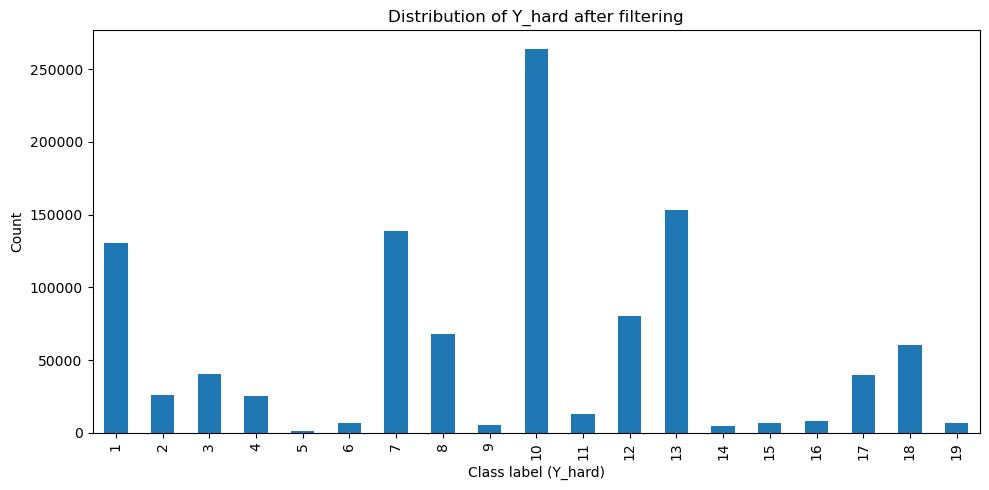

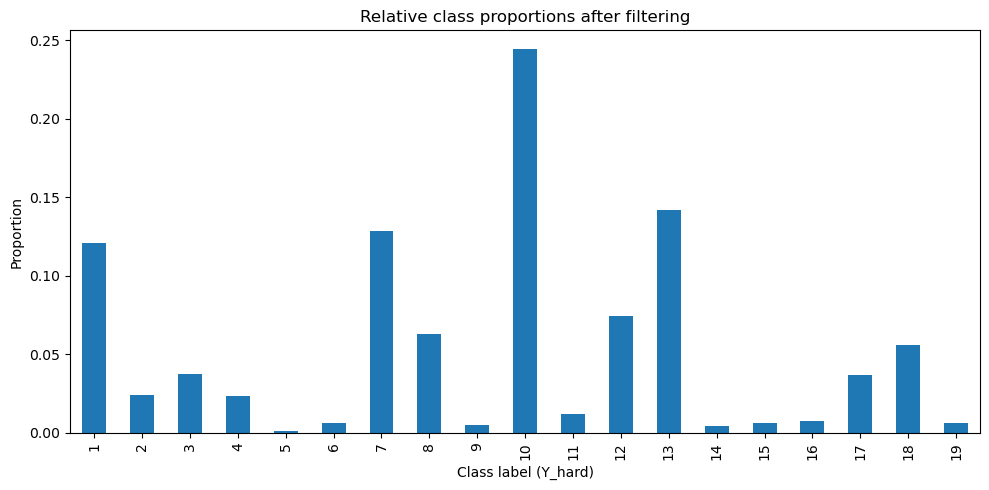

In [27]:
# --- imports ---
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- load learned pattern assignments ---
I_with_patterns = pd.read_pickle("I_with_patterns.pkl")  # has cluster + pat_* + current_*_cls

# reset indices so row alignment is guaranteed
df = df.reset_index(drop=True)
I_with_patterns = I_with_patterns.reset_index(drop=True)
assert len(df) == len(I_with_patterns), "df and I_with_patterns must have same length!"

# --- identify the current_*_cls columns deterministically ---
current_cls_cols = sorted(
    [c for c in I_with_patterns.columns
     if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)
assert len(current_cls_cols) == 16, f"Expected 16 current_*_cls cols, got {len(current_cls_cols)}"

# --- build masks ---
mask_not_all1 = ~(I_with_patterns[current_cls_cols] == 1).all(axis=1)   # not all ones
mask_pat0     = I_with_patterns["pat_0"] <= 0.99                       # not dominated by cluster 0

# combine all filters
keep_mask = mask_not_all1 & mask_pat0
print(f"Total rows: {len(df):,}")
print(f"Keeping: {keep_mask.sum():,}  Dropped: {(~keep_mask).sum():,} "
      f"({(1 - keep_mask.mean())*100:.2f}%)")

# --- filter both dataframes in lockstep ---
df_f              = df.loc[keep_mask.to_numpy()].reset_index(drop=True)
I_with_patterns_f = I_with_patterns.loc[keep_mask.to_numpy()].reset_index(drop=True)

# --- rebuild blocks (same rules as before) ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
proba_cols  = [c for c in I_with_patterns_f.columns if c.startswith("pat_")]
cluster_col = "cluster"

exclude = set(WRENCH_COLS + current_cls_cols + proba_cols + [cluster_col])
feature_cols = [c for c in df_f.columns if c not in exclude]

X_feat_f = df_f.loc[:, feature_cols].apply(pd.to_numeric, errors="coerce").copy()
W_f      = df_f.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()
Y_soft_f = I_with_patterns_f.loc[:, proba_cols].astype("float32").copy()
Y_hard_f = I_with_patterns_f.loc[:, cluster_col].astype("int32").copy()

print(f"X_feat_f: {X_feat_f.shape}  W_f: {W_f.shape}  "
      f"Y_soft_f: {Y_soft_f.shape}  Y_hard_f: {Y_hard_f.shape}  K={len(proba_cols)}")

# --- plots: distribution of Y_hard after filtering ---
counts = pd.Series(Y_hard_f).value_counts().sort_index()

plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.xlabel("Class label (Y_hard)")
plt.ylabel("Count")
plt.title("Distribution of Y_hard after filtering")
plt.tight_layout()

plt.figure(figsize=(10,5))
(counts / counts.sum()).plot(kind='bar')
plt.xlabel("Class label (Y_hard)")
plt.ylabel("Proportion")
plt.title("Relative class proportions after filtering")
plt.tight_layout()
plt.show()


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# use a sample (10k rows)
idx = np.random.choice(len(X_feat_f), size=10000, replace=False)
X_sample = np.hstack([X_feat_f.values[idx], W_f.values[idx]])
y_sample = Y_hard_f.values[idx]

clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf.fit(X_sample, y_sample)
y_pred = clf.predict(X_sample)
print(classification_report(y_sample, y_pred))


/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.25      0.01      0.01      1186
           2       0.00      0.00      0.00       218
           3       0.00      0.00      0.00       408
           4       0.00      0.00      0.00       253
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00        53
           7       0.17      0.00      0.01      1298
           8       0.00      0.00      0.00       607
           9       0.00      0.00      0.00        45
          10       0.24      0.97      0.39      2433
          11       0.00      0.00      0.00       128
          12       0.00      0.00      0.00       746
          13       0.23      0.04      0.07      1433
          14       0.00      0.00      0.00        41
          15       0.00      0.00      0.00        60
          16       0.00      0.00      0.00        86
          17       0.00      0.00      0.00       384
          18       1.00    

/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alireza-linux/.local/lib/python3.12/site-packages/skle

/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731:

Classification report for current_1_cls (on 50000 samples):
              precision    recall  f1-score   support

           0      0.387     0.564     0.459      3874
           1      0.000     0.000     0.000      2295
           2      0.378     0.430     0.402      3831

    accuracy                          0.383     10000
   macro avg      0.255     0.331     0.287     10000
weighted avg      0.295     0.383     0.332     10000



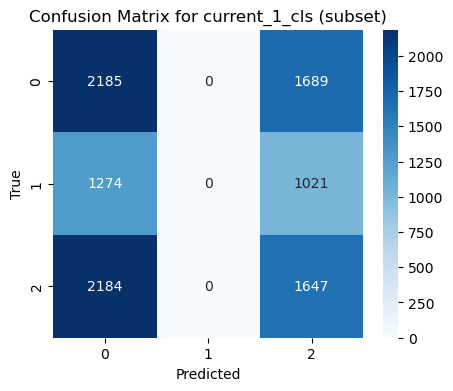

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- pick coil column ---
coil_col = "current_1_cls"
y_coil = I_with_patterns_f[coil_col].values

# --- build full feature matrix ---
X_all = pd.concat([X_feat_f, W_f], axis=1).to_numpy()

# --- sample a manageable subset ---
N_SAMPLES = 50000   # adjust if still too big
idx = np.random.choice(len(X_all), size=N_SAMPLES, replace=False)
X_sub, y_sub = X_all[idx], y_coil[idx]

# --- train/test split ---
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

# --- logistic regression classifier ---
clf = LogisticRegression(max_iter=2000, multi_class="multinomial", n_jobs=-1)
clf.fit(X_tr, y_tr)

# --- predictions ---
y_pred = clf.predict(X_te)

# --- evaluation ---
print(f"Classification report for {coil_col} (on {N_SAMPLES} samples):")
print(classification_report(y_te, y_pred, digits=3))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix for {coil_col} (subset)")
plt.show()


In [28]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# --- Custom Sine Layer (SIREN-style) ---
class SineLayer(layers.Layer):
    def __init__(self, units, omega=30, is_first=False, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.omega = omega
        self.is_first = is_first

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        init_range = 1.0 / in_dim if self.is_first else tf.math.sqrt(6.0 / in_dim) / self.omega
        self.w = self.add_weight(
            name="kernel",
            shape=(in_dim, self.units),
            initializer=tf.random_uniform_initializer(-init_range, init_range),
            trainable=True,
        )
        self.b = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        return tf.sin(self.omega * (tf.matmul(inputs, self.w) + self.b))


# --- Inputs ---
n_features = X_feat_f.shape[1]
inp_feat = Input(shape=(n_features,), name="features")
inp_w    = Input(shape=(6,), name="wrench")

# --- Feature branch ---
f = SineLayer(256, omega=30, is_first=True)(inp_feat)
f = SineLayer(256, omega=30)(f)

# --- Wrench branch ---
w = SineLayer(128, omega=30, is_first=True)(inp_w)
w = SineLayer(128, omega=30)(w)

# --- Fusion ---
x = layers.Concatenate()([f, w])
x = SineLayer(512, omega=30)(x)
x = layers.Dense(512, activation="gelu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="gelu")(x)
x = layers.Dense(128, activation="gelu")(x)

# --- Output: 20 soft targets ---
K = Y_soft_f.shape[1]
out = layers.Dense(K, activation="softmax", name="cluster_soft")(x)

model_soft = Model(inputs=[inp_feat, inp_w], outputs=out)

# --- Compile ---
model_soft.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",  # works on soft targets
    metrics=["accuracy"]
)

model_soft.summary()


I0000 00:00:1755969703.836716  107621 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 118)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrench (InputLayer) │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer          │ (None, 256)       │     30,464 │ features[0][0]    │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_2        │ (None, 128)       │        896 │ wrench[0][0]      │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_1        │ (None, 256)       │     65,792 │ sine_layer[0][0]  │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_3        │ (None, 128)       │     16,512 │ sine_layer_2[0][… │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ sine_layer_1[0][… │
│ (Concatenate)       │                   │            │ sine_layer_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_4        │ (None, 512)       │    197,120 │ concatenate[0][0] │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ sine_layer_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cluster_soft        │ (None, 20)        │      2,580 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 740,244 (2.82 MB)

 Trainable params: 740,244 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from sklearn.utils import resample

# --- attach labels + soft targets ---
df_bal = df_f.copy()
df_bal["Y_hard"] = Y_hard_f.values
for c in Y_soft_f.columns:
    df_bal[c] = Y_soft_f[c].values

# --- target size per class ---
target_total = len(df_f)        # aim near original dataset size
target_per_class = target_total // Y_soft_f.shape[1]
print("Target per class:", target_per_class)

# --- build balanced subset ---
dfs = []
for cid, sub in df_bal.groupby("Y_hard"):
    if len(sub) > target_per_class:
        dfs.append(resample(sub, replace=False, n_samples=target_per_class, random_state=42))  # undersample
    else:
        dfs.append(resample(sub, replace=True, n_samples=target_per_class, random_state=42))   # oversample

df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# --- rebuild arrays ---
X_feat_bal = df_bal[feature_cols].to_numpy()
W_bal      = df_bal[WRENCH_COLS].to_numpy()
Y_soft_bal = df_bal[[c for c in df_bal.columns if c.startswith("pat_")]].to_numpy()
Y_hard_bal = df_bal["Y_hard"].to_numpy()

print("Balanced-subset dataset shapes:",
      X_feat_bal.shape, W_bal.shape, Y_soft_bal.shape, Y_hard_bal.shape)
print("Samples per class:\n", df_bal["Y_hard"].value_counts().sort_index())

# --- Train ---
history = model_soft.fit(
    [X_feat_bal, W_bal],
    Y_soft_bal,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    verbose=1
)


Target per class: 53929
Balanced-subset dataset shapes: (1024651, 118) (1024651, 6) (1024651, 20) (1024651,)
Samples per class:
 Y_hard
1     53929
2     53929
3     53929
4     53929
5     53929
6     53929
7     53929
8     53929
9     53929
10    53929
11    53929
12    53929
13    53929
14    53929
15    53929
16    53929
17    53929
18    53929
19    53929
Name: count, dtype: int64
Epoch 1/5


I0000 00:00:1755969801.251894  108232 service.cc:152] XLA service 0x7acfa40107e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755969801.251915  108232 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-08-23 20:53:21.312046: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755969801.651812  108232 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-23 20:53:23.535303: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_721', 32 bytes spill stores, 32 bytes spill loads

2025-08-23 20:53:25.383182: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

  111/14410 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - accuracy: 0.0534 - loss: 3.0002   

I0000 00:00:1755969813.303820  108232 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14395/14410 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0528 - loss: 2.9466

2025-08-23 20:53:53.682932: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1510', 4 bytes spill stores, 4 bytes spill loads

2025-08-23 20:53:53.807957: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1535', 8 bytes spill stores, 8 bytes spill loads

2025-08-23 20:53:54.931621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1510', 4 bytes spill stores, 4 bytes spill loads

2025-08-23 20:53:55.113375: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1518', 4 bytes spill stores, 4 bytes spill loads

2025-08-23 20:53:55.448005: I external/local_xla

14410/14410 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.0529 - loss: 2.9426 - val_accuracy: 0.0527 - val_loss: 2.9406
Epoch 2/5
14410/14410 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.0526 - loss: 2.9406 - val_accuracy: 0.0526 - val_loss: 2.9403
Epoch 3/5
14410/14410 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.0526 - loss: 2.9406 - val_accuracy: 0.0526 - val_loss: 2.9402
Epoch 4/5
14410/14410 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - accuracy: 0.0526 - loss: 2.9405 - val_accuracy: 0.0526 - val_loss: 2.9403
Epoch 5/5
14410/14410 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.0526 - loss: 2.9405 - val_accuracy: 0.0526 - val_loss: 2.9403


2025-08-23 20:56:35.383102: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47_0', 40 bytes spill stores, 44 bytes spill loads

2025-08-23 20:56:37.051751: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 140 bytes spill stores, 140 bytes spill loads

2025-08-23 20:56:37.306079: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 452 bytes spill stores, 464 bytes spill loads

2025-08-23 20:56:37.895576: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64_0', 1656 bytes spill stores, 1280 bytes spill loads

2025-08-23 20:56:38.566342: I extern

2105/2107 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step

2025-08-23 20:56:41.540442: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_31_0', 16 bytes spill stores, 16 bytes spill loads

2025-08-23 20:56:42.282062: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 16 bytes spill stores, 16 bytes spill loads

2025-08-23 20:56:42.845956: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47_0', 36 bytes spill stores, 40 bytes spill loads

2025-08-23 20:56:43.444429: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 148 bytes spill stores, 148 bytes spill loads

2025-08-23 20:56:43.783351: I external/loc

2107/2107 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step


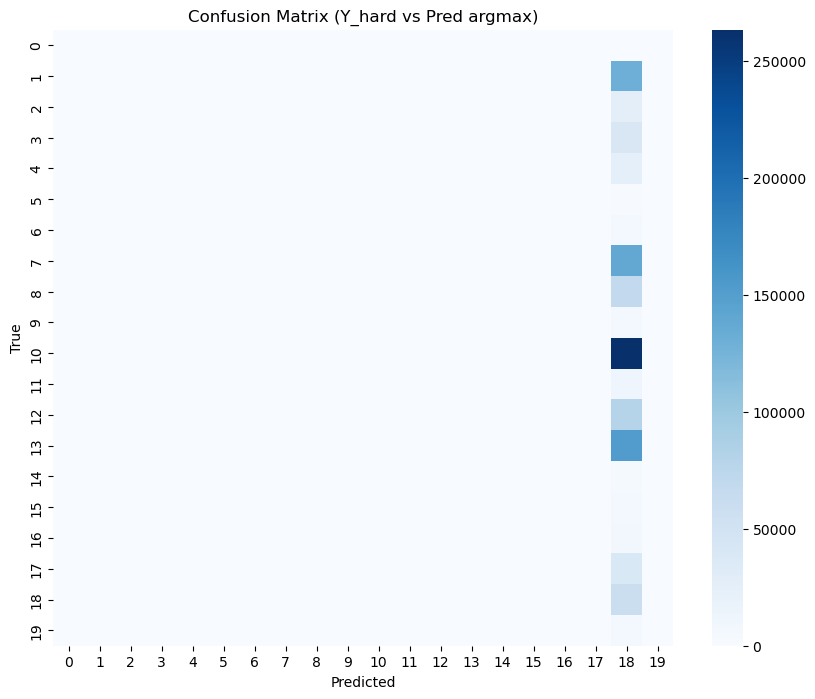

Classification Report (hard labels):


/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

              precision    recall  f1-score   support

           1      0.000     0.000     0.000    130231
           2      0.000     0.000     0.000     26326
           3      0.000     0.000     0.000     40745
           4      0.000     0.000     0.000     25504
           5      0.000     0.000     0.000      1377
           6      0.000     0.000     0.000      6758
           7      0.000     0.000     0.000    138926
           8      0.000     0.000     0.000     68057
           9      0.000     0.000     0.000      5216
          10      0.000     0.000     0.000    263451
          11      0.000     0.000     0.000     13237
          12      0.000     0.000     0.000     80184
          13      0.000     0.000     0.000    153142
          14      0.000     0.000     0.000      4360
          15      0.000     0.000     0.000      6587
          16      0.000     0.000     0.000      8069
          17      0.000     0.000     0.000     39477
          18      0.056    

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Predict on validation split ---
y_true_soft = Y_soft_f.values
y_true_hard = Y_hard_f.values

# predictions
y_pred_soft = model_soft.predict([X_feat_f.values, W_f.values], batch_size=512, verbose=1)
y_pred_hard = np.argmax(y_pred_soft, axis=1)

# --- Confusion Matrix (hard labels) ---
cm = confusion_matrix(y_true_hard, y_pred_hard, labels=np.arange(y_pred_soft.shape[1]))

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=np.arange(y_pred_soft.shape[1]),
            yticklabels=np.arange(y_pred_soft.shape[1]))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Y_hard vs Pred argmax)")
plt.show()

# --- Classification Report ---
print("Classification Report (hard labels):")
print(classification_report(y_true_hard, y_pred_hard, digits=3))

# --- Cross-entropy on soft labels ---
ce_loss = -np.sum(y_true_soft * np.log(y_pred_soft + 1e-9), axis=1).mean()
print(f"Mean cross-entropy against Y_soft: {ce_loss:.4f}")


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# === Prepare dataset (features + wrench + hard labels) ===
X_all = pd.concat([X_feat_f, W_f], axis=1).to_numpy()
y_all = Y_hard_f.to_numpy()

# === Subsample for tractability ===
N_SAMPLES = 200_000   # adjust based on memory
idx = np.random.choice(len(X_all), size=N_SAMPLES, replace=False)
X_sub, y_sub = X_all[idx], y_all[idx]

# === Train/test split ===
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

# === Random Forest ===
rf = RandomForestClassifier(
    n_estimators=300,    # increase for more capacity
    max_depth=None,      # let it grow deep (overfitting allowed)
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")
rf.fit(X_tr, y_tr)

# === Predictions ===
y_pred_tr = rf.predict(X_tr)
y_pred_te = rf.predict(X_te)

# === Reports ===
print("Train classification report:")
print(classification_report(y_tr, y_pred_tr, digits=3))

print("Test classification report:")
print(classification_report(y_te, y_pred_te, digits=3))

# === Confusion matrix on test ===
cm = confusion_matrix(y_te, y_pred_te, labels=np.unique(y_all))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()


Training Random Forest...


In [31]:
print(I_with_patterns_f["current_1_cls"].value_counts())


current_1_cls
0    416361
2    414822
1    247407
Name: count, dtype: int64


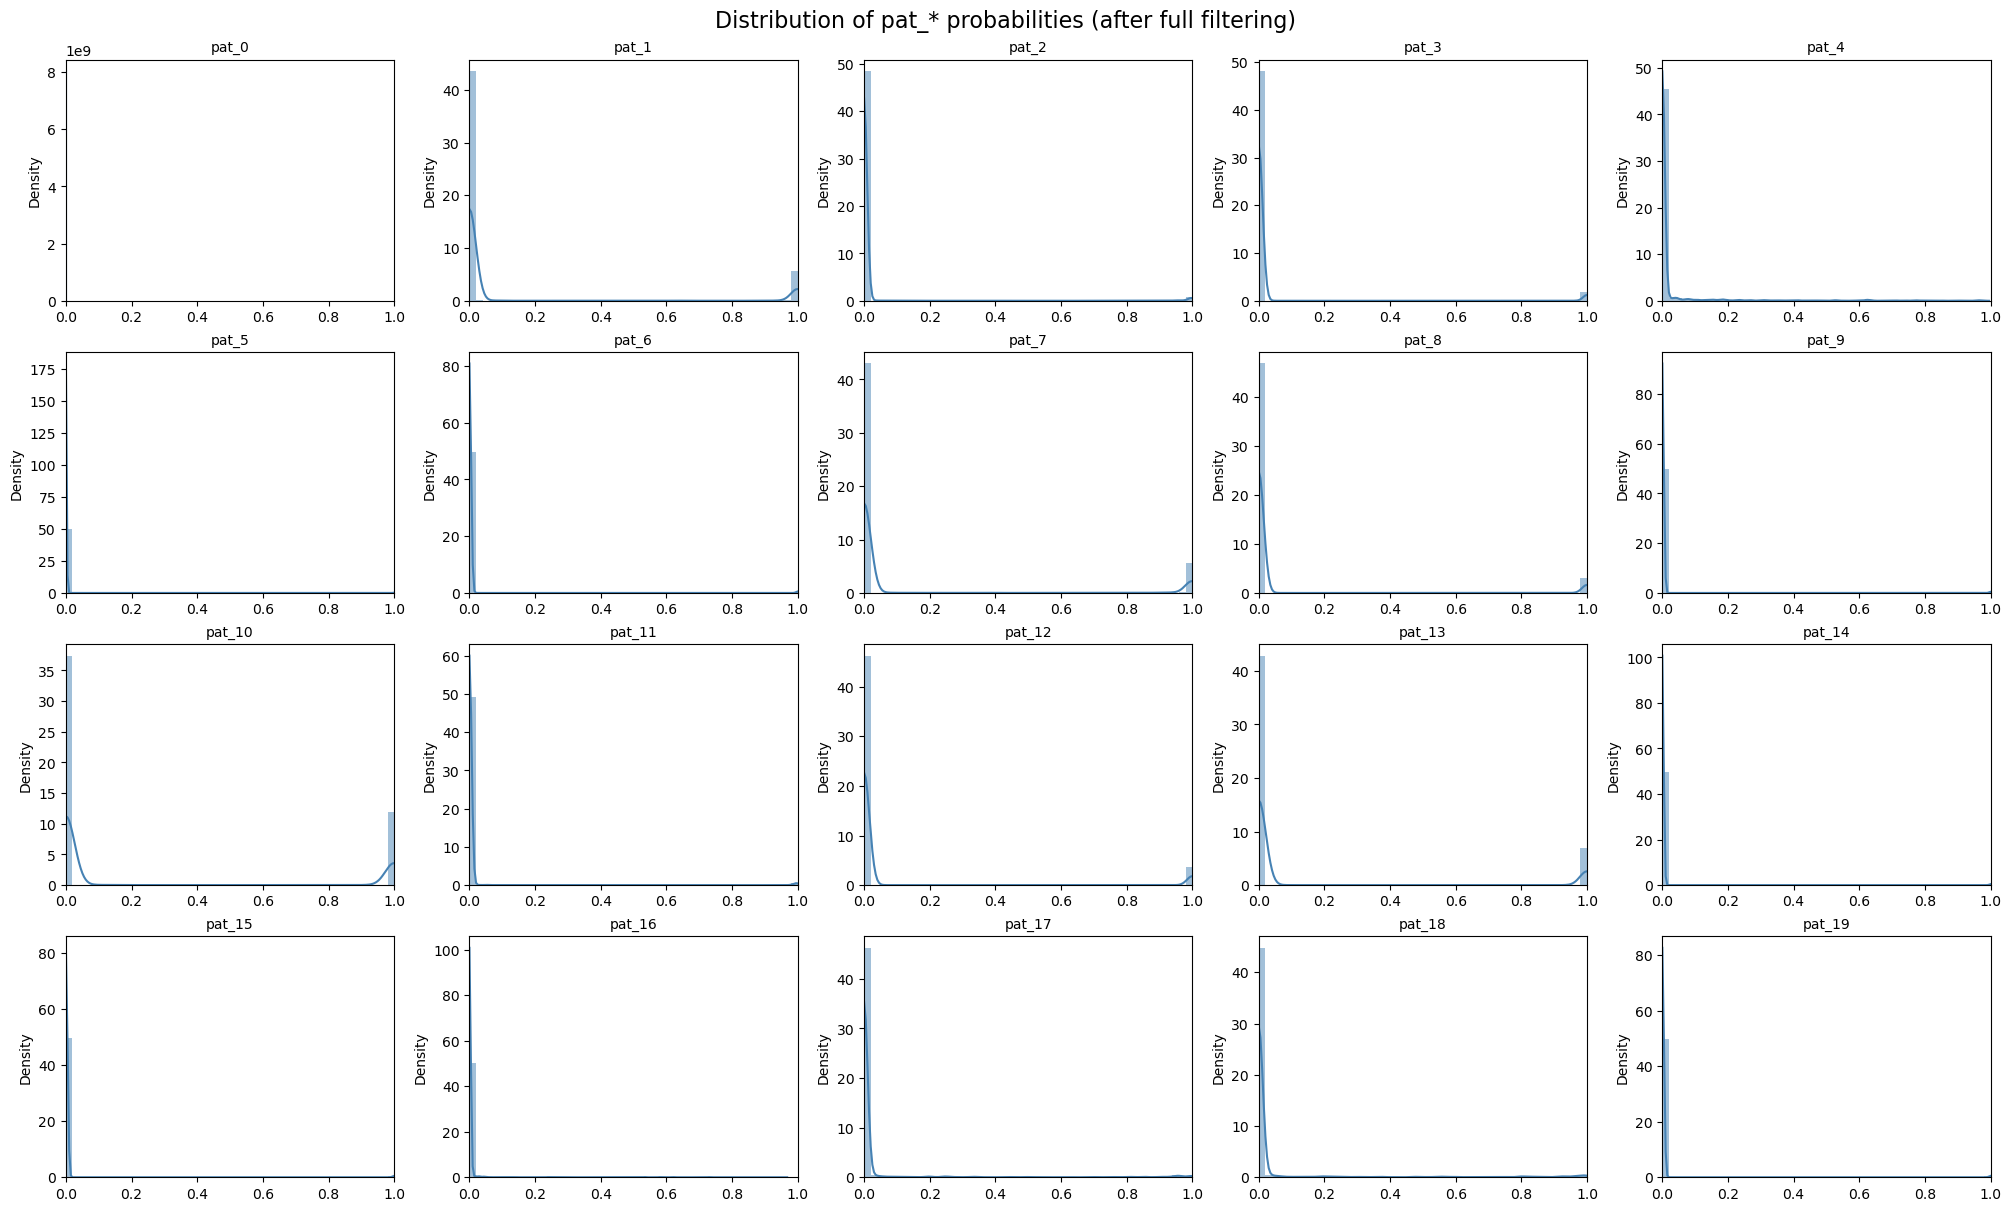

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

pat_cols = [c for c in Y_soft_f.columns if c.startswith("pat_")]
grid_rows, grid_cols = 4, 5

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 12), constrained_layout=True)

for i, col in enumerate(pat_cols):
    ax = axes[i // grid_cols, i % grid_cols]
    
    sns.histplot(
        Y_soft_f[col], 
        bins=50, 
        stat="density", 
        kde=True, 
        color="steelblue", 
        edgecolor=None, 
        ax=ax
    )
    
    ax.set_xlim(0, 1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

# Hide unused axes if any
for j in range(i+1, grid_rows*grid_cols):
    axes[j // grid_cols, j % grid_cols].axis("off")

fig.suptitle("Distribution of pat_* probabilities (after full filtering)", fontsize=16)
plt.show()


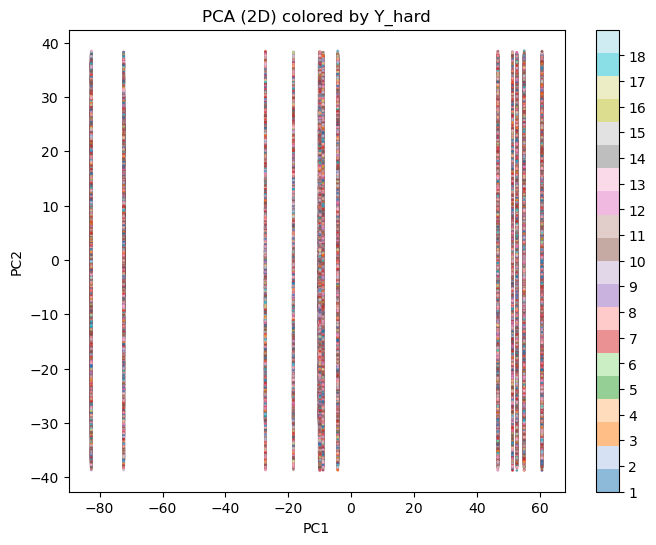

Explained variance ratio: [0.47048838 0.0811515 ]


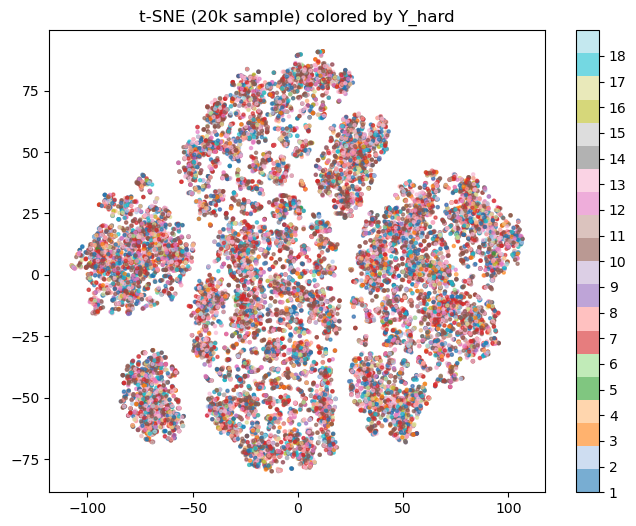

/home/alireza-linux/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



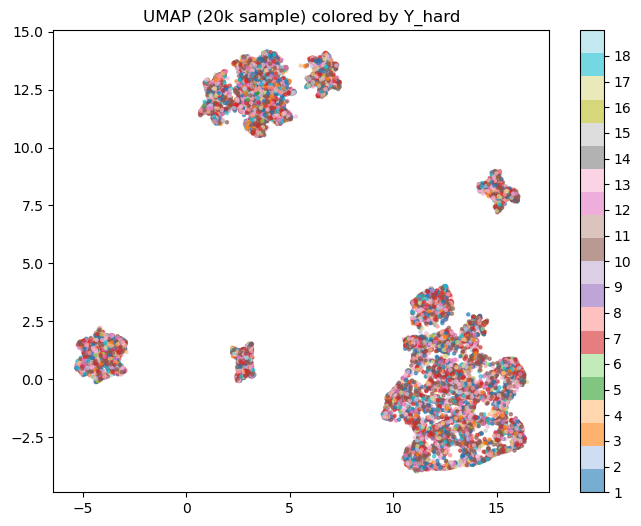

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# === concatenate X and W ===
X_all = pd.concat([X_feat_f, W_f], axis=1).to_numpy()
y = Y_hard_f.to_numpy()

# === PCA ===
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab20', s=1, alpha=0.5)
plt.colorbar(scatter, ticks=range(len(np.unique(y))))
plt.title("PCA (2D) colored by Y_hard")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)




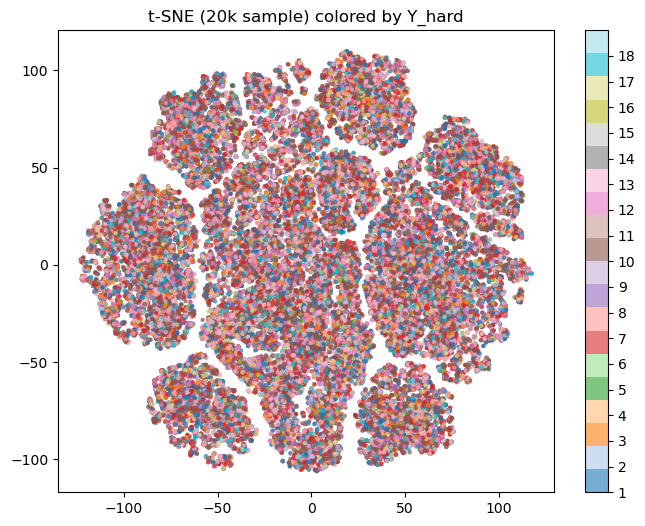

/home/alireza-linux/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



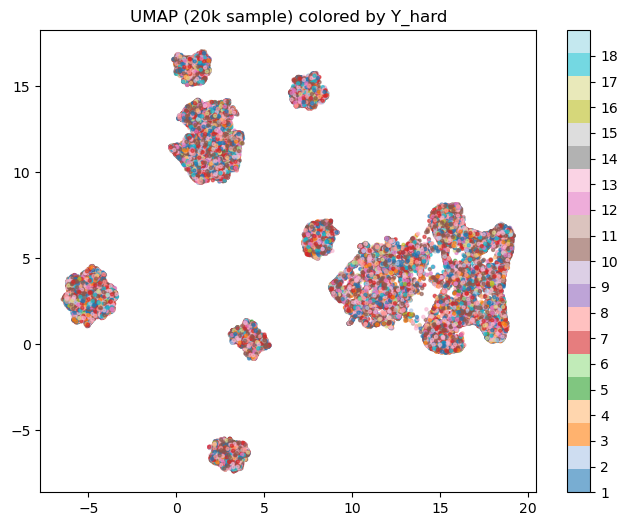

In [56]:
# === Subsample for t-SNE and UMAP (e.g. 20,000 samples) ===
N_SAMPLES = 100000
idx = np.random.choice(len(X_all), size=N_SAMPLES, replace=False)
X_sub, y_sub = X_all[idx], y[idx]

# === t-SNE ===
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sub, cmap='tab20', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(len(np.unique(y))))
plt.title("t-SNE (20k sample) colored by Y_hard")
plt.show()

# === UMAP ===
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_umap = reducer.fit_transform(X_sub)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=y_sub, cmap='tab20', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(len(np.unique(y))))
plt.title("UMAP (20k sample) colored by Y_hard")
plt.show()

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# --- Custom Sine Layer (SIREN-style) ---
class SineLayer(layers.Layer):
    def __init__(self, units, omega=30, is_first=False, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.omega = omega
        self.is_first = is_first

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        init_range = 1.0 / in_dim if self.is_first else tf.math.sqrt(6.0 / in_dim) / self.omega
        self.w = self.add_weight(
            name="kernel",
            shape=(in_dim, self.units),
            initializer=tf.random_uniform_initializer(-init_range, init_range),
            trainable=True,
        )
        self.b = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        return tf.sin(self.omega * (tf.matmul(inputs, self.w) + self.b))


# --- Inputs ---
n_features = X_feat_f.shape[1]
inp_feat = Input(shape=(n_features,), name="features")
inp_w    = Input(shape=(6,), name="wrench")

# --- Feature branch ---
f = SineLayer(256, omega=30, is_first=True)(inp_feat)
f = SineLayer(256, omega=30)(f)

# --- Wrench branch ---
w = SineLayer(128, omega=30, is_first=True)(inp_w)
w = SineLayer(128, omega=30)(w)

# --- Fusion ---
x = layers.Concatenate()([f, w])
x = SineLayer(512, omega=30)(x)
x = layers.Dense(512, activation="gelu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="gelu")(x)
x = layers.Dense(128, activation="gelu")(x)

# --- Output: K=20 classes ---
K = Y_soft_f.shape[1]
out = layers.Dense(K, activation="softmax", name="cluster_pred")(x)

model = Model(inputs=[inp_feat, inp_w], outputs=out)

# --- Compile ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1755965339.175055   71531 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 118)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrench (InputLayer) │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer          │ (None, 256)       │     30,464 │ features[0][0]    │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_2        │ (None, 128)       │        896 │ wrench[0][0]      │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_1        │ (None, 256)       │     65,792 │ sine_layer[0][0]  │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_3        │ (None, 128)       │     16,512 │ sine_layer_2[0][… │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ sine_layer_1[0][… │
│ (Concatenate)       │                   │            │ sine_layer_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_layer_4        │ (None, 512)       │    197,120 │ concatenate[0][0] │
│ (SineLayer)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ sine_layer_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cluster_pred        │ (None, 20)        │      2,580 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 740,244 (2.82 MB)

 Trainable params: 740,244 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(Y_hard_f)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=Y_hard_f.values
)
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

history = model.fit(
    [X_feat_f.values, W_f.values], 
    tf.keras.utils.to_categorical(Y_hard_f, num_classes=Y_soft_f.shape[1]),
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, chkpt],
    verbose=1
)


{1: 0.43590154983715174, 2: 2.1563433387845516, 3: 1.393248122146082, 4: 2.225842798652843, 5: 41.22577686045178, 6: 8.400102802137038, 7: 0.40861965893239643, 8: 0.8341227902617233, 9: 10.883415402001937, 10: 0.21547800060292846, 11: 4.288577074627341, 12: 0.7079703524000063, 13: 0.37068795455748327, 14: 13.02015934331241, 15: 8.618171358257493, 16: 7.035307316500447, 17: 1.4379992080665225, 18: 0.9389952153110048, 19: 8.751024315838155}
Epoch 1/5
15162/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0723 - loss: 2.9665

2025-08-23 19:32:39.280511: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1516', 4 bytes spill stores, 4 bytes spill loads

2025-08-23 19:32:39.630240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_768_0', 16 bytes spill stores, 16 bytes spill loads

2025-08-23 19:32:39.974862: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_723', 44 bytes spill stores, 44 bytes spill loads

2025-08-23 19:32:40.090850: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1524', 8 bytes spill stores, 8 bytes spill loads

2025-08-23 19:32:41.000729: I external/local

15168/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0723 - loss: 2.9664

2025-08-23 19:32:52.859075: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_76', 32 bytes spill stores, 32 bytes spill loads

2025-08-23 19:32:53.179109: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_92', 20 bytes spill stores, 20 bytes spill loads

2025-08-23 19:32:53.361291: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_109', 32 bytes spill stores, 32 bytes spill loads

2025-08-23 19:32:53.419769: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_92', 32 bytes spill stores, 32 bytes spill loads

2025-08-23 19:32:53.565348: I external/local_xl


Epoch 1: val_accuracy did not improve from 0.24449
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.0517 - loss: 2.9505 - val_accuracy: 0.0116 - val_loss: 2.9428
Epoch 2/5
15162/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0150 - loss: 2.9466
Epoch 2: val_accuracy did not improve from 0.24449
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.0159 - loss: 2.9464 - val_accuracy: 0.0015 - val_loss: 2.9523
Epoch 3/5
15152/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0147 - loss: 2.9408
Epoch 3: val_accuracy did not improve from 0.24449
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.0188 - loss: 2.9463 - val_accuracy: 0.0116 - val_loss: 2.9565
Epoch 4/5
15140/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0078 - loss: 2.9489
Epoch 4: val_accuracy did not improve from 0.24449
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.0099 - loss: 2.9463 - val_accuracy: 0.0238 - val_loss: 2.9343
Epoch 5/5
15136/15168 ━━━━━━━━━━━━━━━━━━

In [31]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# === Prepare labels (use Y_hard_f → one-hot) ===
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(Y_hard_f, num_classes=Y_soft_f.shape[1])

# === Build tf.data.Dataset for efficiency ===
BATCH_SIZE = 64   # safe default, increase to 1024 if memory allows
SHUFFLE_BUF = 10000

ds = tf.data.Dataset.from_tensor_slices(((X_feat_f.values, W_f.values), y_train))
ds = ds.shuffle(SHUFFLE_BUF, reshuffle_each_iteration=True)
ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# === Validation split (e.g., 10%) ===
N = len(X_feat_f)
val_size = int(0.1 * N)
ds_val = ds.take(val_size // BATCH_SIZE)
ds_train = ds.skip(val_size // BATCH_SIZE)

# === Callbacks ===
early_stop = EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)
chkpt = ModelCheckpoint(
    "best_cluster_model.keras", monitor="val_accuracy",
    save_best_only=True, verbose=1
)

# === Train ===
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=5,
    callbacks=[early_stop, chkpt],
    verbose=1
)


Epoch 1/5


I0000 00:00:1755964570.321467   62988 service.cc:152] XLA service 0x79c6e8002400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755964570.321487   62988 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-08-23 19:26:10.380261: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755964570.677730   62988 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-23 19:26:12.687118: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_725', 32 bytes spill stores, 32 bytes spill loads

2025-08-23 19:26:14.587885: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion

  108/15168 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - accuracy: 0.1987 - loss: 2.5075   

I0000 00:00:1755964582.355093   62988 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15134/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2428 - loss: 2.3467

2025-08-23 19:26:44.240684: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_725', 44 bytes spill stores, 44 bytes spill loads

2025-08-23 19:26:44.835102: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1539', 4 bytes spill stores, 4 bytes spill loads

2025-08-23 19:26:45.010409: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_770', 540 bytes spill stores, 552 bytes spill loads

2025-08-23 19:26:45.059484: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 8 bytes spill stores, 8 bytes spill loads

2025-08-23 19:26:45.176920: I external/local

15168/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2429 - loss: 2.3467
Epoch 1: val_accuracy improved from None to 0.24420, saving model to best_cluster_model.keras
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.2440 - loss: 2.3402 - val_accuracy: 0.2442 - val_loss: 2.3342
Epoch 2/5
15153/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2442 - loss: 2.3367
Epoch 2: val_accuracy improved from 0.24420 to 0.24449, saving model to best_cluster_model.keras
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.2442 - loss: 2.3366 - val_accuracy: 0.2445 - val_loss: 2.3332
Epoch 3/5
15142/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2446 - loss: 2.3353
Epoch 3: val_accuracy did not improve from 0.24449
15168/15168 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - accuracy: 0.2443 - loss: 2.3360 - val_accuracy: 0.2438 - val_loss: 2.3340
Epoch 4/5
15164/15168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2444 - loss: 2.3349
Epoch 4: val_accuracy did not improve from 0.2

In [ ]:
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical

# attach hard labels
df_bal = df_f.copy()
df_bal["Y_hard"] = Y_hard_f.values

# find the size of the largest class
max_size = df_bal["Y_hard"].value_counts().max()
dfs = []

# oversample each cluster to the max_size
for cid, sub in df_bal.groupby("Y_hard"):
    dfs.append(resample(sub, replace=True, n_samples=max_size, random_state=42))

df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# rebuild
X_feat_bal = df_bal[feature_cols].to_numpy()
W_bal      = df_bal[WRENCH_COLS].to_numpy()
Y_hard_bal = df_bal["Y_hard"].to_numpy()
y_bal      = to_categorical(Y_hard_bal, num_classes=Y_soft_f.shape[1])

print("Balanced dataset shape:", X_feat_bal.shape, W_bal.shape, y_bal.shape)
print("Samples per class:\n", df_bal["Y_hard"].value_counts())

# === Train ===
history = model.fit(
    [X_feat_bal, W_bal],
    y_bal,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, chkpt],
    verbose=1
)


2107/2107 ━━━━━━━━━━━━━━━━━━━━ 2s 840us/step


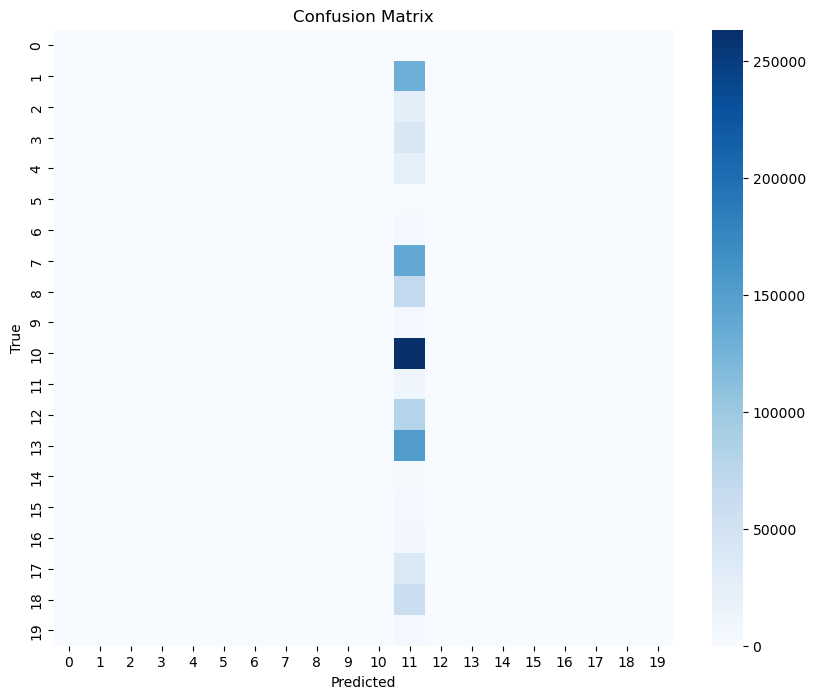

              precision    recall  f1-score   support

           1      0.125     0.000     0.000    130231
           2      0.000     0.000     0.000     26326
           3      0.000     0.000     0.000     40745
           4      0.000     0.000     0.000     25504
           5      0.000     0.000     0.000      1377
           6      0.000     0.000     0.000      6758
           7      0.000     0.000     0.000    138926
           8      0.000     0.000     0.000     68057
           9      0.000     0.000     0.000      5216
          10      0.000     0.000     0.000    263451
          11      0.012     1.000     0.024     13237
          12      0.000     0.000     0.000     80184
          13      0.000     0.000     0.000    153142
          14      0.000     0.000     0.000      4360
          15      0.000     0.000     0.000      6587
          16      0.000     0.000     0.000      8069
          17      0.000     0.000     0.000     39477
          18      0.000    

/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# === Predict on whole dataset (careful: might be heavy) ===
y_true = Y_hard_f.values
y_pred_probs = model.predict([X_feat_f.values, W_f.values], batch_size=512, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Confusion matrix ===
cm = confusion_matrix(y_true, y_pred, labels=np.arange(y_pred_probs.shape[1]))

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=np.arange(y_pred_probs.shape[1]),
            yticklabels=np.arange(y_pred_probs.shape[1]))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# === Classification report ===
report = classification_report(y_true, y_pred, digits=3)
print(report)


In [33]:
from sklearn.utils import resample

df_bal = df_f.copy()
df_bal["Y_hard"] = Y_hard_f.values

dfs = []
min_size = df_bal["Y_hard"].value_counts().min()

for cid, sub in df_bal.groupby("Y_hard"):
    dfs.append(resample(sub, replace=False, n_samples=min_size, random_state=42))

df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Rebuild balanced blocks
X_feat_bal = df_bal[feature_cols]
W_bal      = df_bal[WRENCH_COLS]
Y_hard_bal = df_bal["Y_hard"]
Y_soft_bal = Y_soft_f.loc[df_bal.index]


In [41]:
print("Unique values in pat_0:", Y_soft["pat_0"].unique())
print("Value counts in pat_0:\n", Y_soft["pat_0"].value_counts(normalize=True).head())


Unique values in pat_0: [1.0000000e+00 0.0000000e+00 1.1970102e-19 3.6194836e-19 8.3110035e-07
 5.5557925e-38 7.8457406e-17]
Value counts in pat_0:
 pat_0
0.000000e+00    8.388058e-01
1.000000e+00    1.611903e-01
1.197010e-19    7.766037e-07
3.619484e-19    7.766037e-07
8.311004e-07    7.766037e-07
Name: proportion, dtype: float64


In [42]:
import numpy as np
import pandas as pd

summary = []
eps = 1e-6  # tolerance to treat as "zero"
for col in Y_soft.columns:
    vals = Y_soft[col].values
    n = len(vals)
    n_zeros = np.sum(np.isclose(vals, 0, atol=eps))
    n_ones  = np.sum(np.isclose(vals, 1, atol=eps))
    n_other = n - n_zeros - n_ones
    unique_vals = np.unique(np.round(vals, 6))[:10]  # show first 10 unique rounded
    summary.append({
        "col": col,
        "zeros_%": n_zeros/n*100,
        "ones_%": n_ones/n*100,
        "other_%": n_other/n*100,
        "sample_uniques": unique_vals
    })

df_summary = pd.DataFrame(summary)
pd.set_option("display.max_rows", None)
print(df_summary)


       col    zeros_%     ones_%    other_%  \
0    pat_0  83.880968  16.119032   0.000000   
1    pat_1  84.245662   5.845574   9.908765   
2    pat_2  91.935980   0.000000   8.064020   
3    pat_3  96.559956   2.394580   1.045464   
4    pat_4  71.498566   0.000000  28.501434   
5    pat_5  99.890577   0.108103   0.001320   
6    pat_6  99.469114   0.520713   0.010174   
7    pat_7  82.059677   4.774482  13.165841   
8    pat_8  94.599032   4.798790   0.602179   
9    pat_9  99.583896   0.399485   0.016619   
10  pat_10  76.127978  14.196549   9.675473   
11  pat_11  96.279758   0.000000   3.720242   
12  pat_12  93.695298   5.316629   0.988073   
13  pat_13  87.857102  11.365596   0.777303   
14  pat_14  99.659770   0.166970   0.173260   
15  pat_15  99.488140   0.501686   0.010174   
16  pat_16  83.968103   0.000000  16.031897   
17  pat_17  81.246263   0.000000  18.753737   
18  pat_18  67.366335   0.000000  32.633665   
19  pat_19  99.486665   0.497182   0.016153   

            

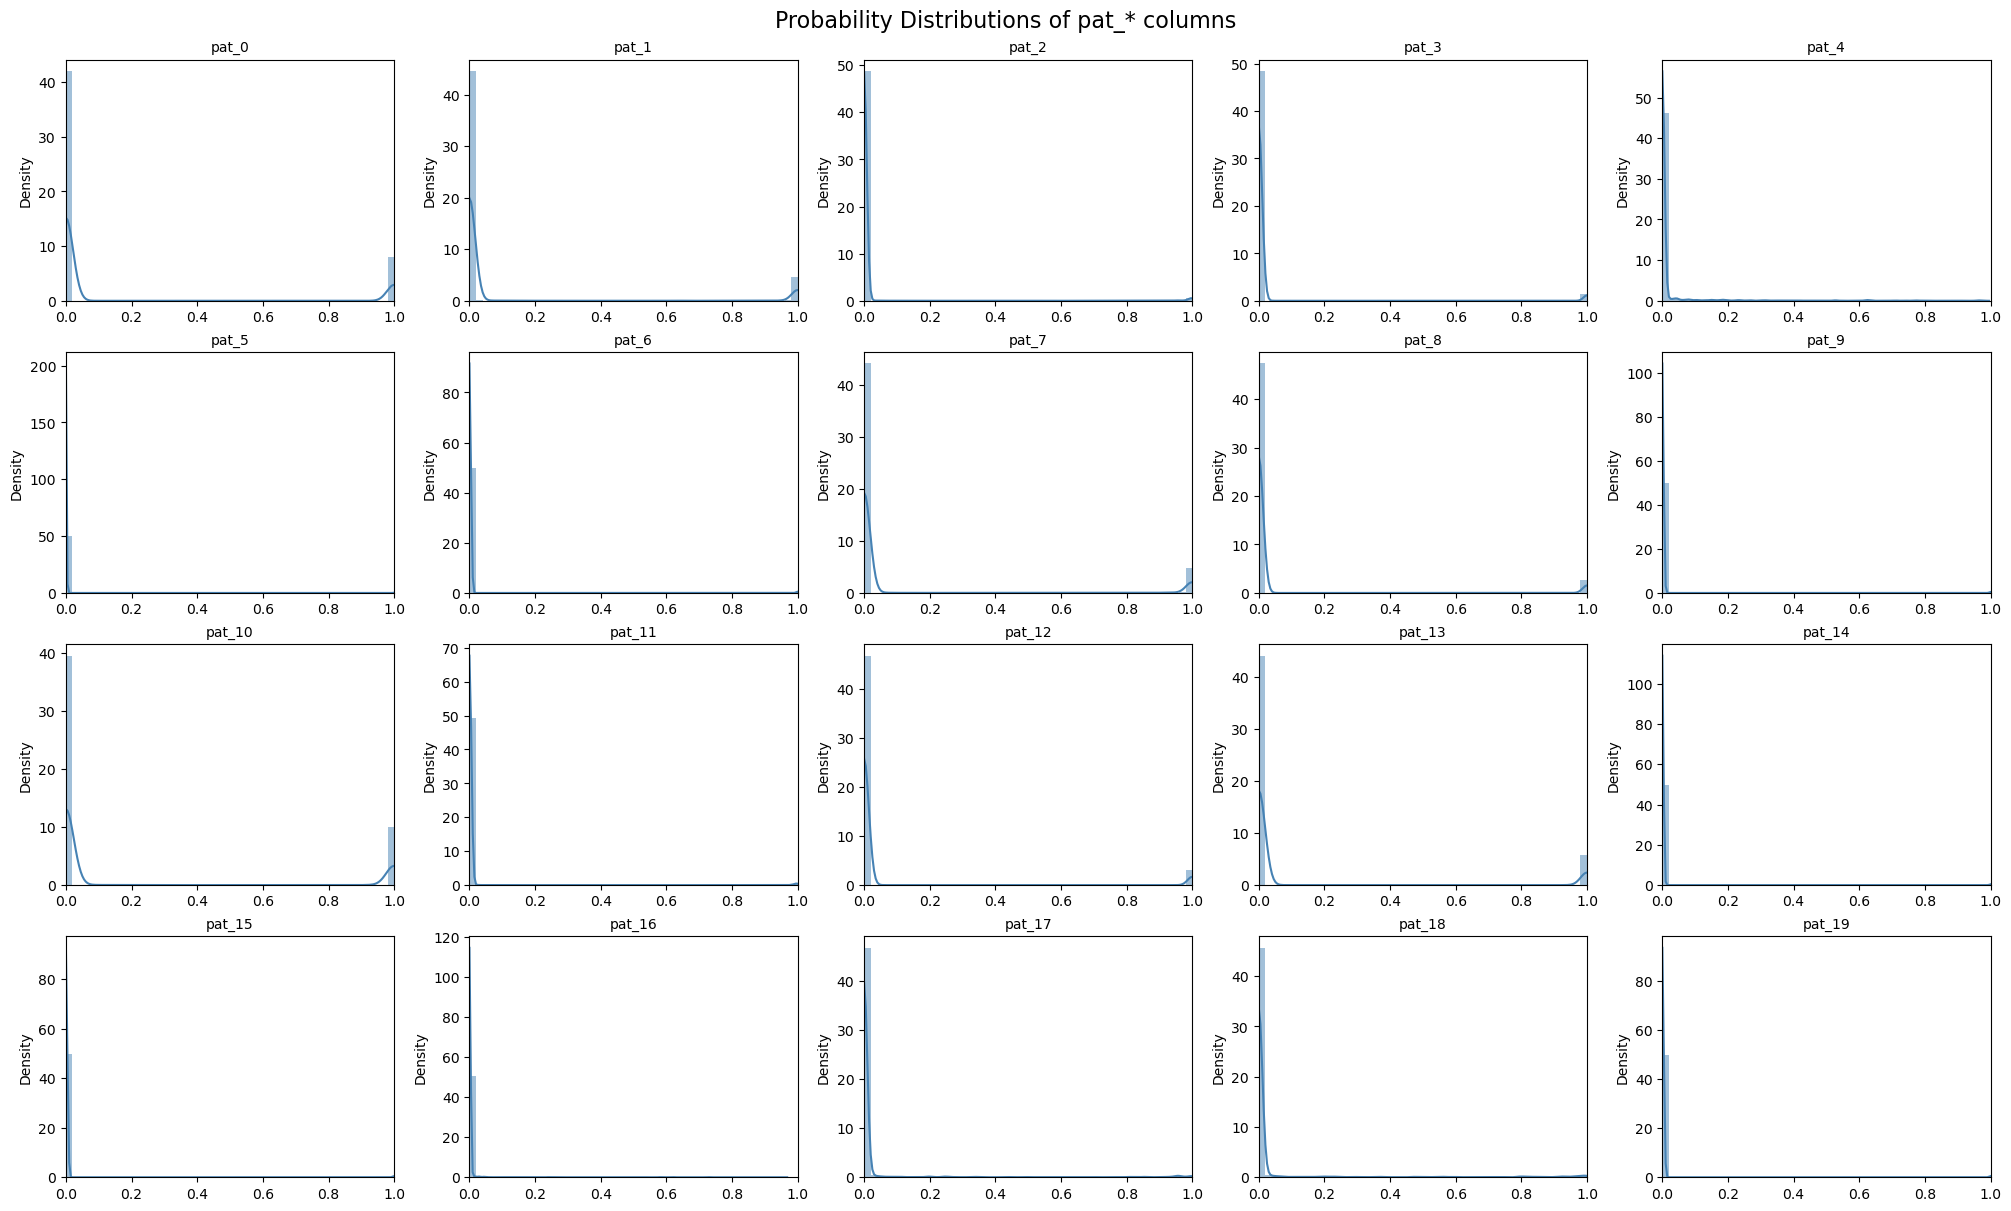

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

pat_cols = [c for c in Y_soft.columns if c.startswith("pat_")]
n_cols = len(pat_cols)
grid_rows, grid_cols = 4, 5

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 12), constrained_layout=True)

for i, col in enumerate(pat_cols):
    ax = axes[i // grid_cols, i % grid_cols]
    
    # plot histogram + KDE
    sns.histplot(Y_soft[col], bins=50, stat="density", kde=True,
                 color="steelblue", edgecolor=None, ax=ax)
    
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylabel("Density")
    ax.set_xlabel("")

# Hide unused axes
for j in range(i+1, grid_rows*grid_cols):
    axes[j // grid_cols, j % grid_cols].axis("off")

fig.suptitle("Probability Distributions of pat_* columns", fontsize=16)
plt.show()


Dropped 32,465 rows (2.92%).  Kept: 1,078,590
Shapes → X: (1078590, 118) W: (1078590, 6) Y_soft: (1078590, 20) Y_hard: (1078590,)


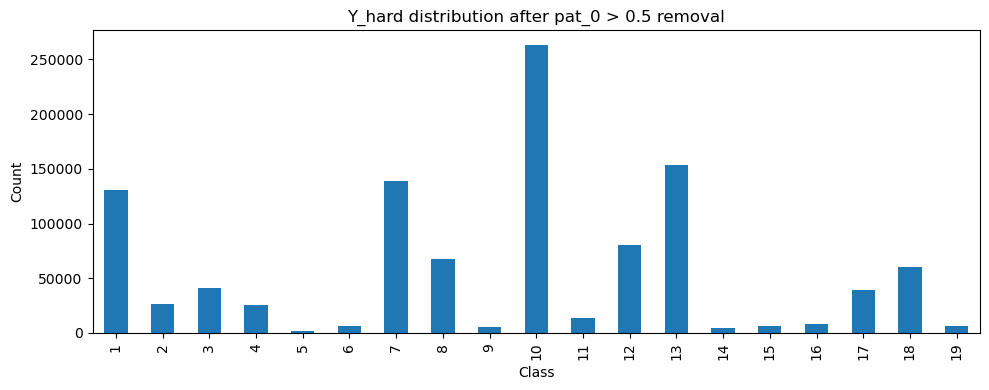

In [ ]:
# === choose the current working frames (fallback to originals if _f not defined) ===
DF_ip = I_with_patterns_f if 'I_with_patterns_f' in locals() else I_with_patterns
X_in  = X_feat_f           if 'X_feat_f'           in locals() else X_feat
W_in  = W_f                if 'W_f'                in locals() else W
Ysf   = Y_soft_f           if 'Y_soft_f'           in locals() else Y_soft
Yhf   = Y_hard_f           if 'Y_hard_f'           in locals() else Y_hard

# === exact column for cluster 0 probability ===
assert "pat_0" in Ysf.columns, f"'pat_0' not found in Y_soft columns: {list(Ysf.columns)[:10]}..."
pat0_col = "pat_0"

# === keep rows where pat_0 <= 0.5 (drop where > 0.5) ===
keep_mask2 = (Ysf[pat0_col] <= 0.5).to_numpy()
idx_keep2 = keep_mask2.nonzero()[0]

# === filter everything in lockstep ===
X_feat_ff            = X_in.loc[keep_mask2].reset_index(drop=True)
W_ff                 = W_in.loc[keep_mask2].reset_index(drop=True)
Y_soft_ff            = Ysf.loc[keep_mask2].reset_index(drop=True)
Y_hard_ff            = Yhf.loc[keep_mask2].reset_index(drop=True)
I_with_patterns_ff   = DF_ip.loc[keep_mask2].reset_index(drop=True)

print(f"Dropped {(~keep_mask2).sum():,} rows "
      f"({(1 - keep_mask2.mean())*100:.2f}%).  Kept: {keep_mask2.sum():,}")
print("Shapes →",
      "X:", X_feat_ff.shape,
      "W:", W_ff.shape,
      "Y_soft:", Y_soft_ff.shape,
      "Y_hard:", Y_hard_ff.shape)

# === OPTIONAL: quick plot of Y_hard distribution after filter ===
# (comment out if you don't want plots)
import pandas as pd, matplotlib.pyplot as plt
counts = pd.Series(Y_hard_ff).value_counts().sort_index()
plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.title("Y_hard distribution after pat_0 > 0.5 removal")
plt.xlabel("Class"); plt.ylabel("Count"); plt.tight_layout()
# plt.show()


In [50]:
import re
import pandas as pd

# Step 1: identify current_*_cls columns
current_cls_cols = sorted(
    [c for c in I_with_patterns.columns if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)
assert len(current_cls_cols) == 16, f"Expected 16 cls cols, got {len(current_cls_cols)}"

# Step 2: mask for rows where all currents == 1
mask_all1 = (I_with_patterns[current_cls_cols] == 1).all(axis=1)

# Step 3: group by cluster, exclude cluster 0
summary = (
    I_with_patterns[mask_all1]
    .groupby("cluster")
    .size()
    .rename("all1_count")
    .to_frame()
)

# add total per cluster for percentages
cluster_sizes = I_with_patterns.groupby("cluster").size().rename("cluster_size")
summary = summary.join(cluster_sizes, how="left")
summary["percent_in_cluster"] = 100 * summary["all1_count"] / summary["cluster_size"]

# filter out cluster 0
summary = summary[summary.index != 0].sort_index()

print(summary)


         all1_count  cluster_size  percent_in_cluster
cluster                                              
4                 1         25505            0.003921
5                19          1396            1.361032
6                 7          6765            0.103474
9                10          5226            0.191351
11              164         13401            1.223789
14               14          4374            0.320073
15                4          6591            0.060689
17              956         40433            2.364405
18              319         60775            0.524887
19               16          6503            0.246040


In [51]:
import re

# === Step 1: identify current_*_cls columns ===
current_cls_cols = sorted(
    [c for c in I_with_patterns_ff.columns if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

# === Step 2: mask for rows where NOT all currents == 1 ===
mask_not_all1 = ~(I_with_patterns_ff[current_cls_cols] == 1).all(axis=1)

# === Step 3: filter all aligned dataframes ===
X_feat_final  = X_feat_ff.loc[mask_not_all1].reset_index(drop=True)
W_final       = W_ff.loc[mask_not_all1].reset_index(drop=True)
Y_soft_final  = Y_soft_ff.loc[mask_not_all1].reset_index(drop=True)
Y_hard_final  = Y_hard_ff.loc[mask_not_all1].reset_index(drop=True)
I_with_patterns_final = I_with_patterns_ff.loc[mask_not_all1].reset_index(drop=True)

# === Step 4: report ===
removed = (~mask_not_all1).sum()
print(f"Dropped {removed:,} rows (all currents==1 across ANY cluster).")
print("Final shapes:",
      "X:", X_feat_final.shape,
      "W:", W_final.shape,
      "Y_soft:", Y_soft_final.shape,
      "Y_hard:", Y_hard_final.shape)


Dropped 0 rows (all currents==1 across ANY cluster).
Final shapes: X: (1078590, 118) W: (1078590, 6) Y_soft: (1078590, 20) Y_hard: (1078590,)


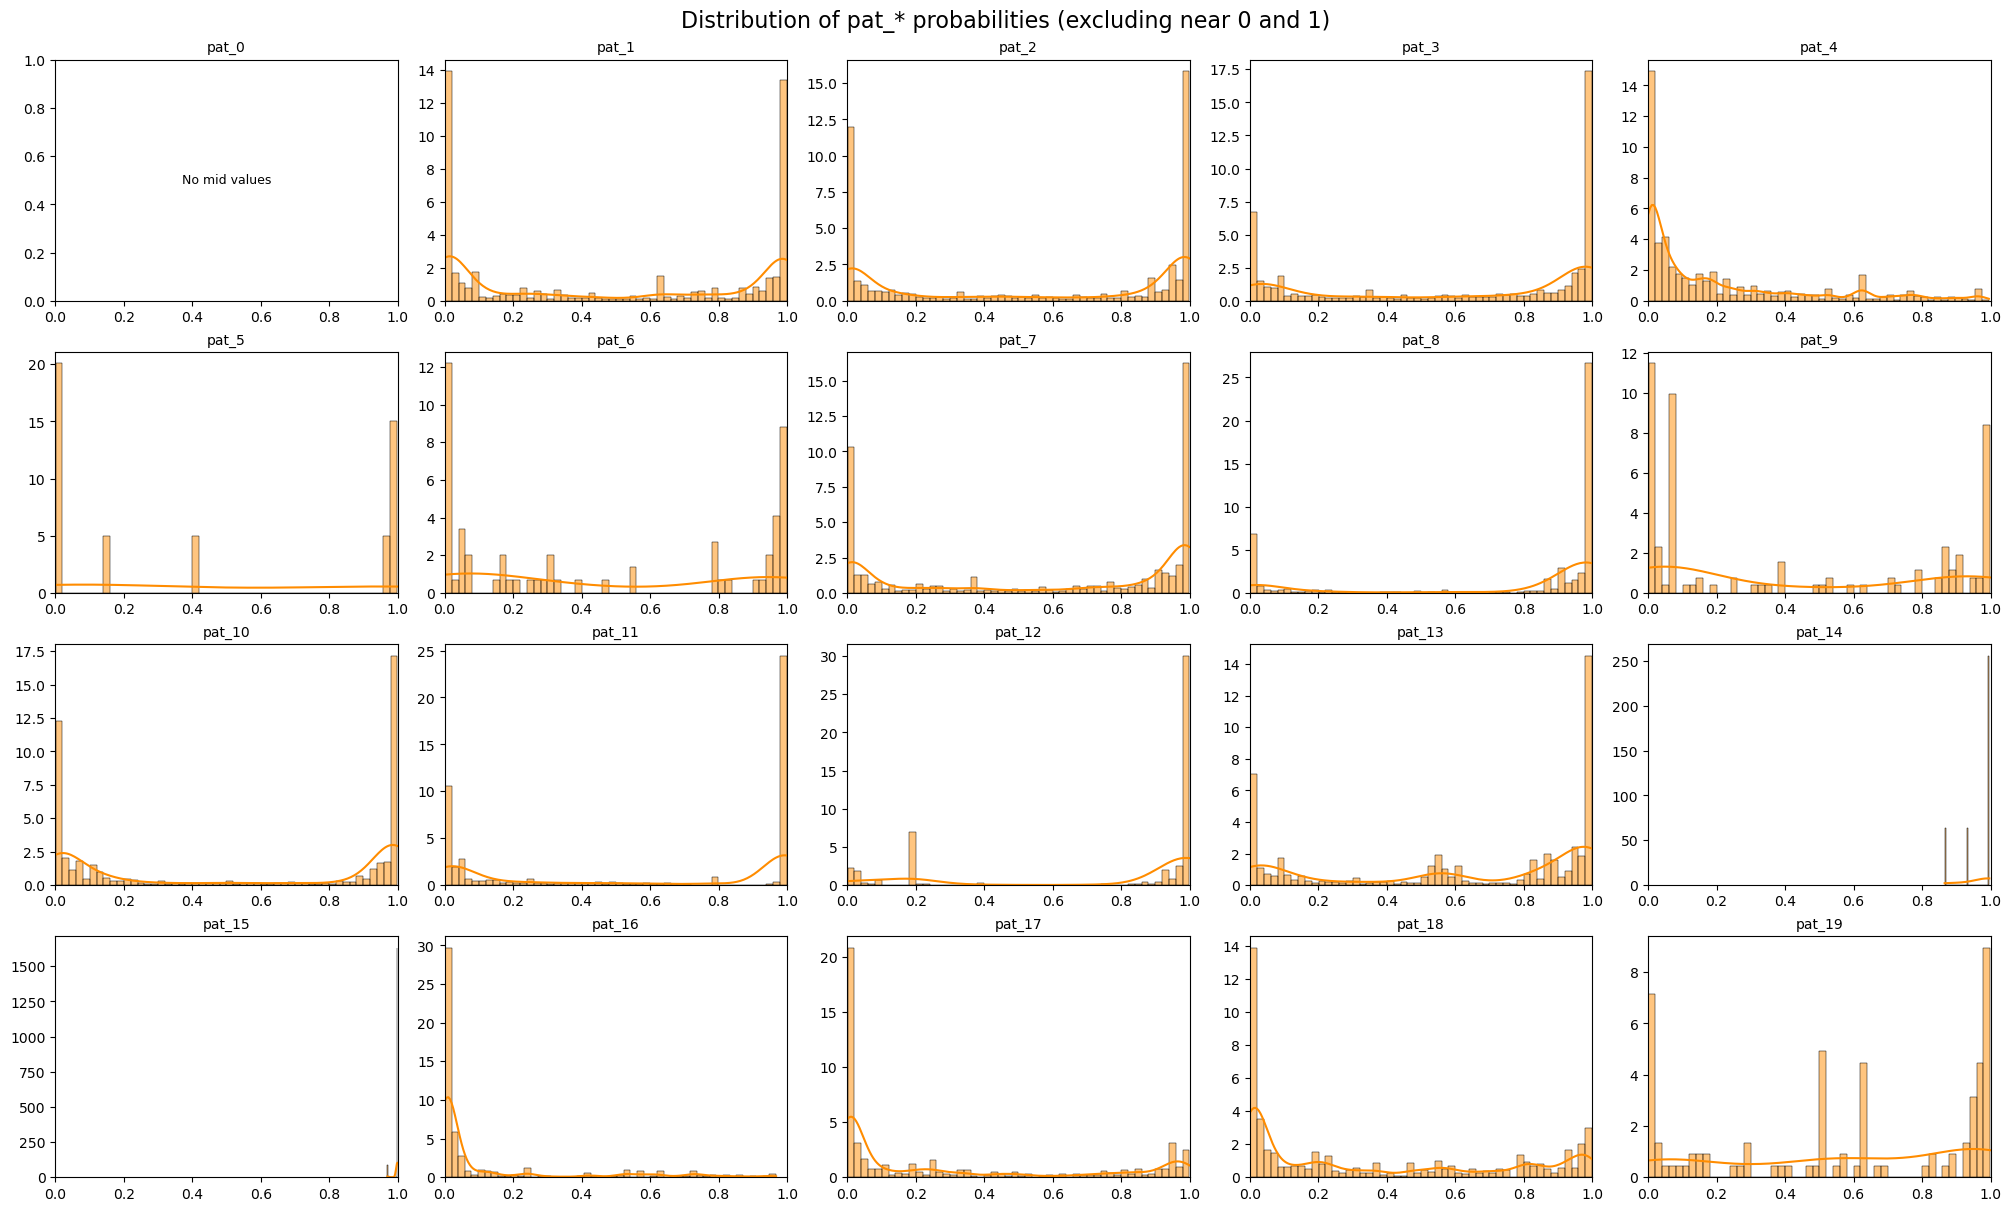

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pat_cols = [c for c in Y_soft.columns if c.startswith("pat_")]
grid_rows, grid_cols = 4, 5

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 12), constrained_layout=True)

for i, col in enumerate(pat_cols):
    ax = axes[i // grid_cols, i % grid_cols]
    vals = Y_soft[col].values
    mask = (vals > 1e-3) & (vals < 1-1e-3)
    vals_mid = vals[mask]
    
    if len(vals_mid) > 0:
        sns.histplot(vals_mid, bins=50, kde=True, color="darkorange", stat="density", ax=ax)
        ax.set_xlim(0, 1)
    else:
        ax.text(0.5, 0.5, "No mid values", ha="center", va="center", fontsize=9)
        ax.set_xlim(0, 1)
    
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide unused axes if any
for j in range(i+1, grid_rows*grid_cols):
    axes[j // grid_cols, j % grid_cols].axis("off")

fig.suptitle("Distribution of pat_* probabilities (excluding near 0 and 1)", fontsize=16)
plt.show()


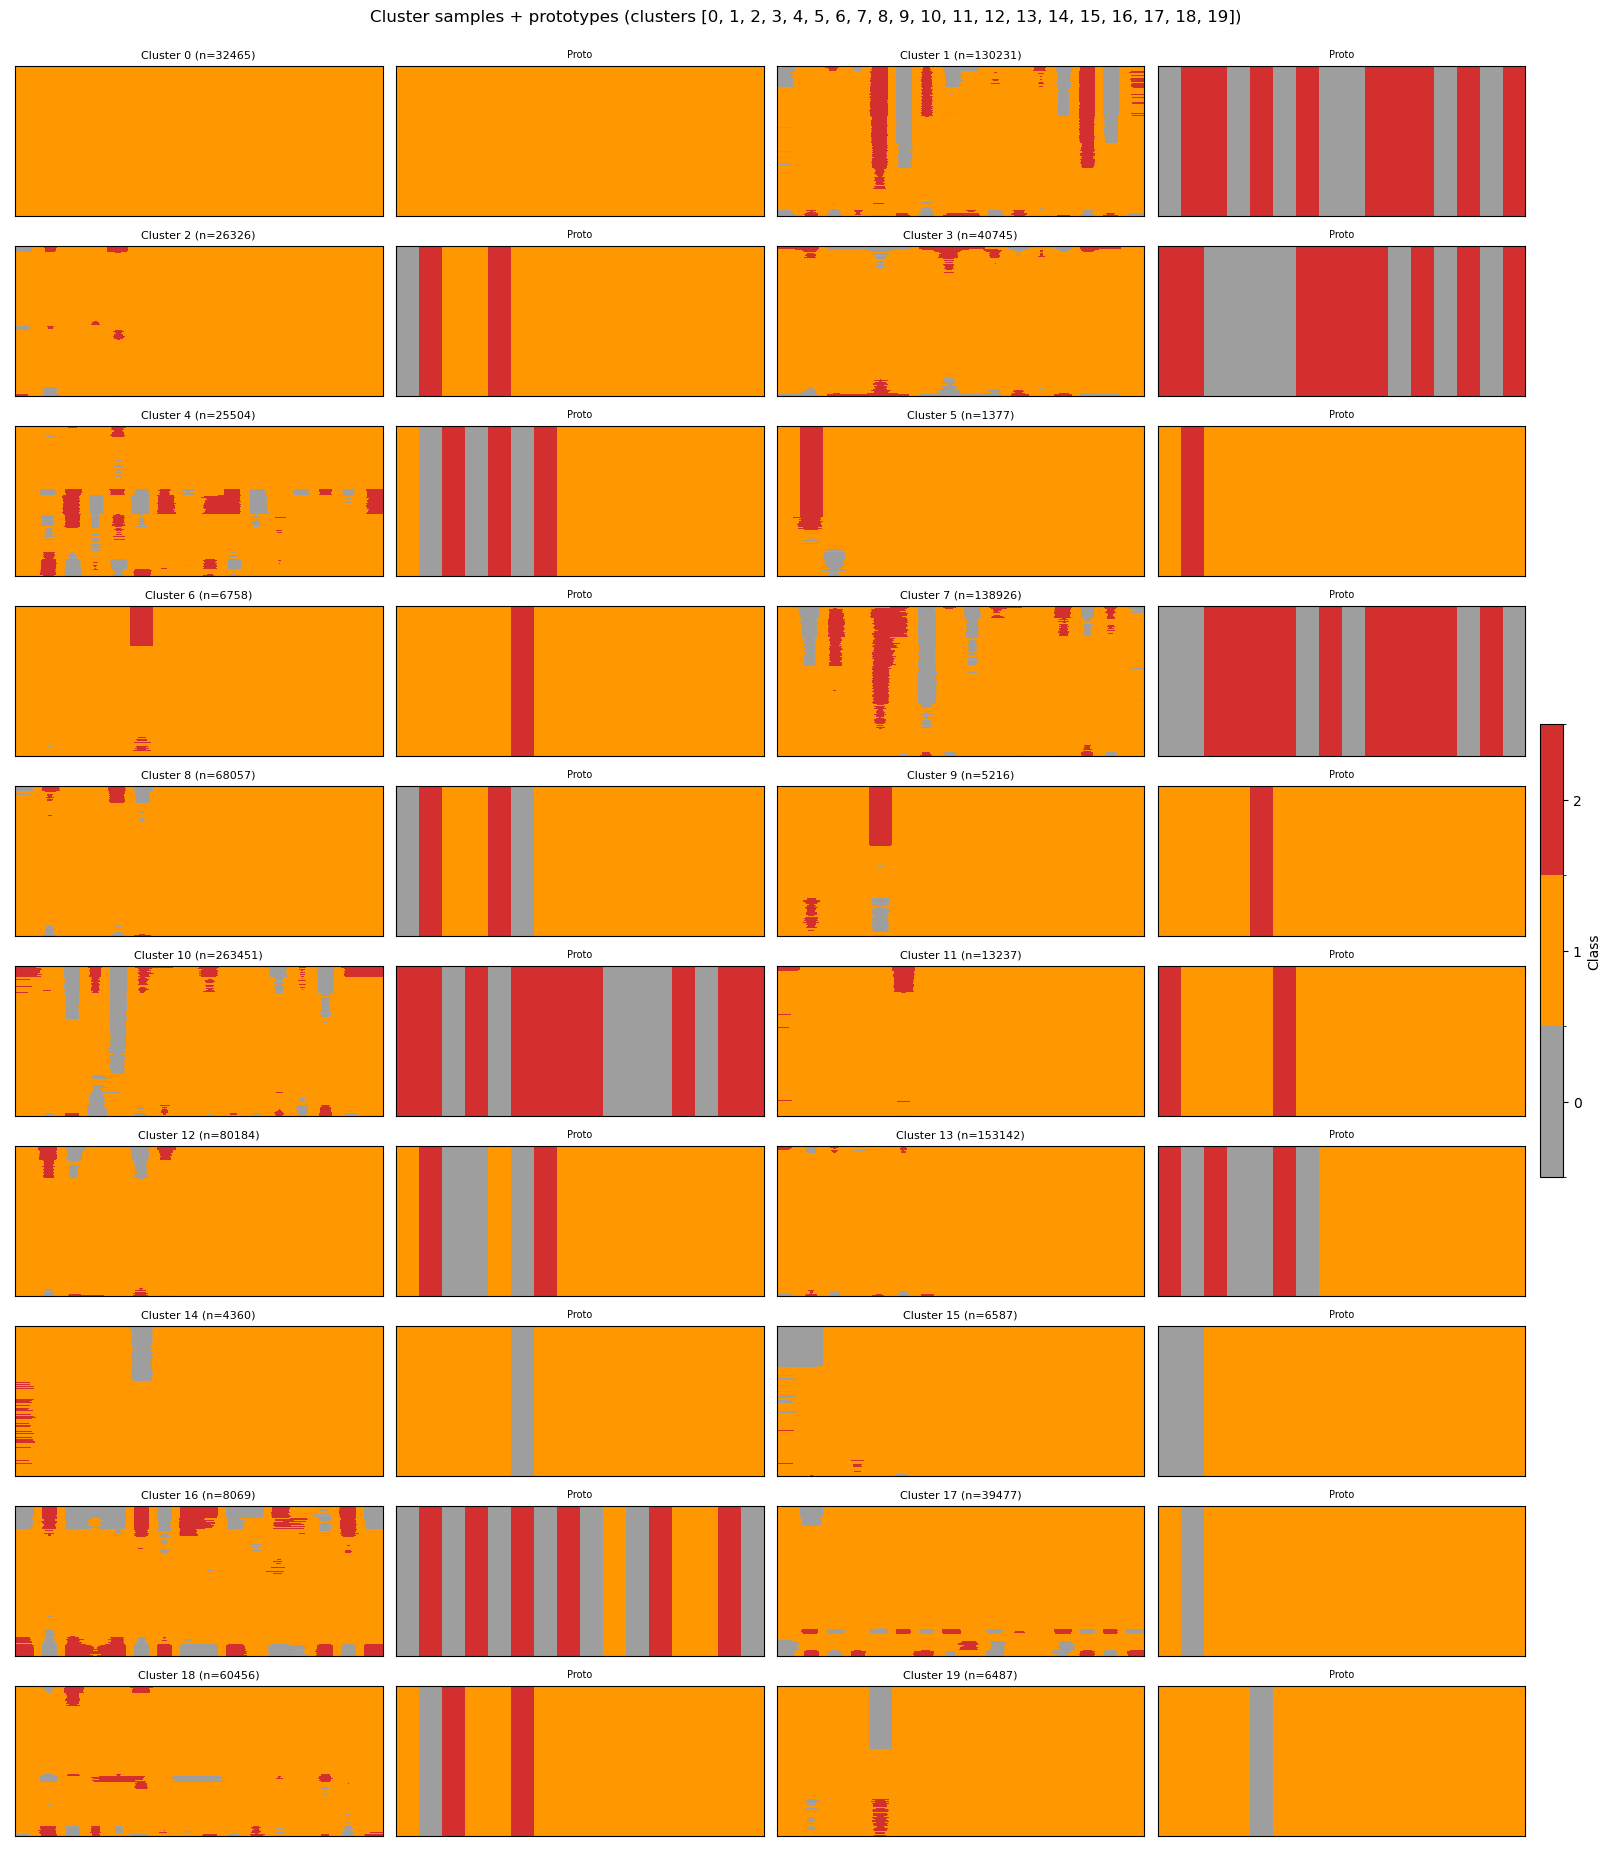

In [33]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==== use filtered dataframe ====
DF = I_with_patterns_f  # <- changed from I_with_patterns

# config
MAX_ROWS_PER_CLUSTER = 1_000_000
GRID_ROWS, GRID_COLS = 5, 4
SORT_BY_SIMILARITY = True

# only current_*_cls columns, sorted by coil index
feat_order = sorted(
    [c for c in DF.columns if c.startswith("current_") and c.endswith("_cls")],
    key=lambda c: int(re.search(r"\d+", c).group())
)

clusters = sorted(DF["cluster"].unique())

cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

def hamming(a, b):
    return (a != b).sum(axis=1)

per_page = GRID_ROWS * GRID_COLS
for page_start in range(0, len(clusters), per_page):
    page_clusters = clusters[page_start:page_start+per_page]

    fig, axes = plt.subplots(GRID_ROWS*2, GRID_COLS, figsize=(4*GRID_COLS, 1.8*GRID_ROWS*2),
                             constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for j, cid in enumerate(page_clusters):
        sub = DF.loc[DF["cluster"] == cid, feat_order].astype(int)
        proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

        if SORT_BY_SIMILARITY:
            d = hamming(sub.values, proto)
            order = np.argsort(d)
            sub = sub.iloc[order]

        if len(sub) > MAX_ROWS_PER_CLUSTER:
            idx = np.random.choice(len(sub), size=MAX_ROWS_PER_CLUSTER, replace=False)
            sub = sub.iloc[idx]

        grid_pos = j*2
        ax_samples = axes[grid_pos]
        last_im = ax_samples.imshow(sub.values, aspect="auto", cmap=cmap, norm=norm)
        ax_samples.set_title(f"Cluster {cid} (n={len(sub)})", fontsize=8)
        ax_samples.set_xticks([]); ax_samples.set_yticks([])

        ax_proto = axes[grid_pos+1]
        ax_proto.imshow(proto, aspect="auto", cmap=cmap, norm=norm)
        ax_proto.set_xticks([]); ax_proto.set_yticks([])
        ax_proto.set_title("Proto", fontsize=7)

    for ax in axes[len(page_clusters)*2:]:
        ax.axis("off")

    fig.colorbar(last_im, ax=axes, ticks=[0,1,2], fraction=0.015, pad=0.01, label="Class")
    fig.suptitle(f"Cluster samples + prototypes (clusters {page_clusters})", y=1.02)
    # plt.show()  # uncomment to render


Filtered out: 176,603 rows (13.72%).  Kept: 1,111,055
X_feat_f: (1111055, 118)  W_f: (1111055, 6)  Y_soft_f: (1111055, 20)  Y_hard_f: (1111055,)  K=20


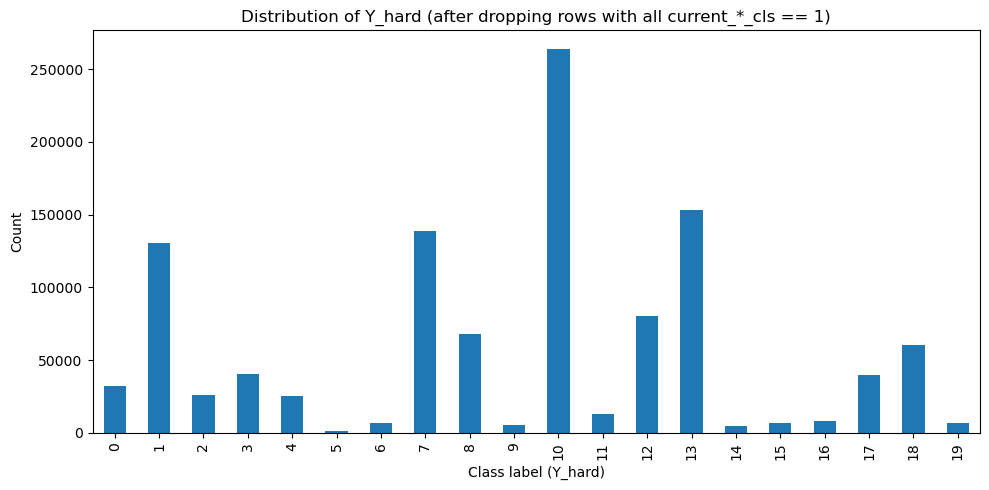

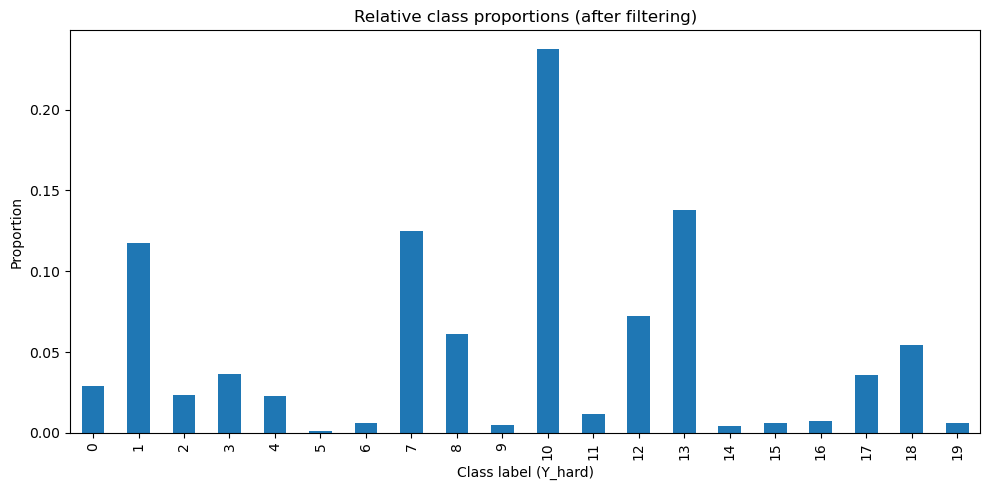

In [32]:
# --- identify the current_*_cls columns deterministically ---
import re
current_cls_cols = sorted(
    [c for c in I_with_patterns.columns
     if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)
assert len(current_cls_cols) == 16, f"Expected 16 current_*_cls cols, got {len(current_cls_cols)}"

# --- build keep mask: keep rows where NOT(all current_*_cls == 1) ---
keep_mask = ~(I_with_patterns[current_cls_cols] == 1).all(axis=1)
keep_idx  = keep_mask.to_numpy().nonzero()[0]   # optional: indices for later reuse

# --- filter both dataframes in lockstep (temporary; no disk writes) ---
df_f              = df.loc[keep_mask].reset_index(drop=True)
I_with_patterns_f = I_with_patterns.loc[keep_mask].reset_index(drop=True)

print(f"Filtered out: {len(df) - len(df_f):,} rows "
      f"({(1 - len(df_f)/len(df)) * 100:.2f}%).  Kept: {len(df_f):,}")

# --- rebuild blocks (same rules as before) ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
proba_cols  = [c for c in I_with_patterns_f.columns if c.startswith("pat_")]
cluster_col = "cluster"

exclude = set(WRENCH_COLS + current_cls_cols + proba_cols + [cluster_col])
feature_cols = [c for c in df_f.columns if c not in exclude]

X_feat_f = df_f.loc[:, feature_cols].apply(pd.to_numeric, errors="coerce").copy()
W_f      = df_f.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()
Y_soft_f = I_with_patterns_f.loc[:, proba_cols].astype("float32").copy()
Y_hard_f = I_with_patterns_f.loc[:, cluster_col].astype("int32").copy()

print(f"X_feat_f: {X_feat_f.shape}  W_f: {W_f.shape}  Y_soft_f: {Y_soft_f.shape}  "
      f"Y_hard_f: {Y_hard_f.shape}  K={len(proba_cols)}")

# --- plots: distribution of Y_hard after filtering ---
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.Series(Y_hard_f).value_counts().sort_index()

plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.xlabel("Class label (Y_hard)")
plt.ylabel("Count")
plt.title("Distribution of Y_hard (after dropping rows with all current_*_cls == 1)")
plt.tight_layout()
# plt.show()  # uncomment to render

plt.figure(figsize=(10,5))
(counts / counts.sum()).plot(kind='bar')
plt.xlabel("Class label (Y_hard)")
plt.ylabel("Proportion")
plt.title("Relative class proportions (after filtering)")
plt.tight_layout()
# plt.show()  # uncomment to render


In [31]:
I_with_patterns.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,...,pat_10,pat_11,pat_12,pat_13,pat_14,pat_15,pat_16,pat_17,pat_18,pat_19
0,1,1,1,1,1,1,1,1,1,1,...,1.258643e-226,6.612444e-24,0.000000e+00,0.000000e+00,1.941852e-54,0.0,1.252746e-41,2.440567e-18,2.448054e-19,0.0
1,2,2,1,2,2,1,0,1,1,1,...,3.969409e-89,7.641373e-26,9.562642e-45,3.887431e-80,1.545347e-67,0.0,5.953941e-25,5.169663e-12,7.317963e-13,0.0
2,1,1,0,2,1,0,2,1,1,1,...,9.124360e-84,1.454533e-101,9.999971e-01,7.207187e-74,1.167700e-95,0.0,1.219232e-19,4.513328e-10,4.724653e-10,0.0
3,1,1,1,0,1,1,1,1,1,1,...,2.030073e-75,9.840893e-01,9.745965e-312,0.000000e+00,1.498549e-131,0.0,2.264839e-11,9.101343e-03,6.806883e-03,0.0
4,0,0,0,2,2,2,0,2,1,1,...,1.559638e-100,2.166963e-48,4.256599e-32,1.000000e+00,1.287160e-86,0.0,2.512135e-25,9.867977e-13,4.400651e-13,0.0


In [27]:
# --- load learned pattern assignments ---
import pandas as pd
I_with_patterns = pd.read_pickle("I_with_patterns.pkl")  # has cluster + pat_* + current_*_cls

# sanity: align rows with your original df
df = df.reset_index(drop=True)
I_with_patterns = I_with_patterns.reset_index(drop=True)
assert len(df) == len(I_with_patterns)

# --- column sets ---
import re
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]

# original current-class columns (if you still need them for analysis)
current_cls_cols = sorted(
    [c for c in I_with_patterns.columns if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

# soft pattern targets
proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
K = len(proba_cols)

# optional hard target (cluster id)
cluster_col = "cluster"

# --- build blocks (features/inputs unchanged; targets = soft probs) ---
# features = everything EXCEPT wrench + current_*_cls + pat_* + cluster
exclude = set(WRENCH_COLS + current_cls_cols + proba_cols + [cluster_col])
feature_cols = [c for c in df.columns if c not in exclude]

X_feat = df.loc[:, feature_cols].apply(pd.to_numeric, errors="coerce").copy()
W      = df.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()

# targets
Y_soft = I_with_patterns.loc[:, proba_cols].astype("float32").copy()   # (N, K) mixture weights
Y_hard = I_with_patterns.loc[:, cluster_col].astype("int32").copy()    # (N,) optional

print(f"X_feat: {X_feat.shape}  W: {W.shape}  Y_soft: {Y_soft.shape}  K={K}")


X_feat: (1287658, 118)  W: (1287658, 6)  Y_soft: (1287658, 20)  K=20


In [28]:
print(f"X_feat: {X_feat.shape}  W: {W.shape}  Y_soft: {Y_soft.shape}  Y_hard: {Y_hard.shape} K={K}")


X_feat: (1287658, 118)  W: (1287658, 6)  Y_soft: (1287658, 20)  Y_hard: (1287658,) K=20


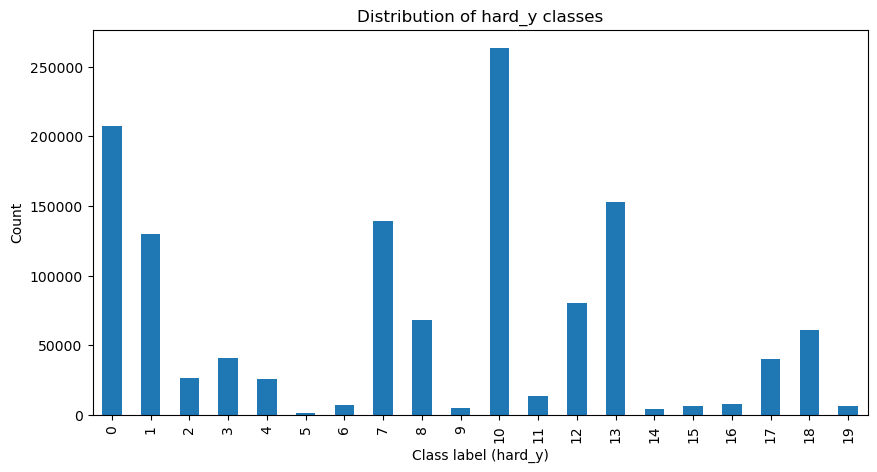

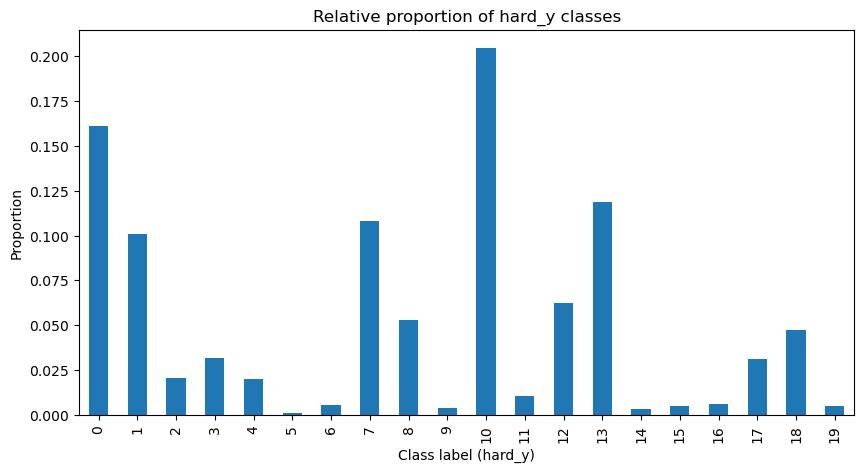

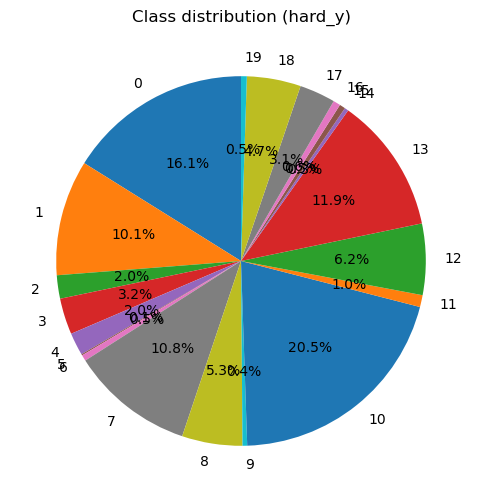

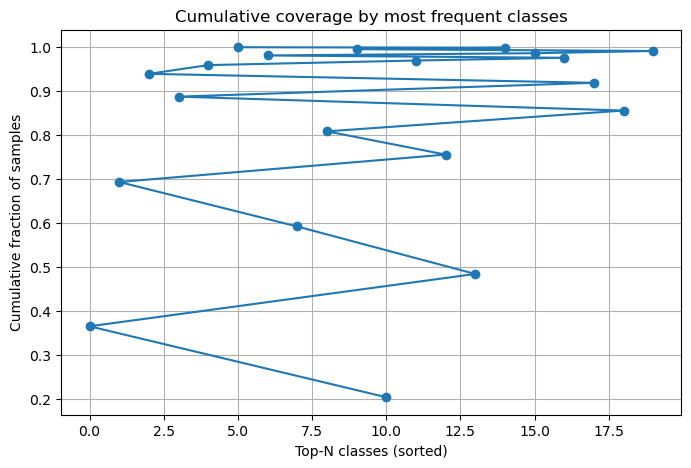

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have Y_hard as numpy array
y = Y_hard  # shape (1287658,)

# Step 1 — class counts
counts = pd.Series(y).value_counts().sort_index()

# Step 2 — raw counts bar plot
plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.xlabel("Class label (hard_y)")
plt.ylabel("Count")
plt.title("Distribution of hard_y classes")
plt.show()

# Step 3 — normalized proportions
plt.figure(figsize=(10,5))
(counts / counts.sum()).plot(kind='bar')
plt.xlabel("Class label (hard_y)")
plt.ylabel("Proportion")
plt.title("Relative proportion of hard_y classes")
plt.show()

# Step 4 — optional: pie chart
plt.figure(figsize=(6,6))
(counts / counts.sum()).plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Class distribution (hard_y)")
plt.ylabel("")
plt.show()

# Step 5 — cumulative distribution
plt.figure(figsize=(8,5))
(counts.sort_values(ascending=False).cumsum() / counts.sum()).plot(marker='o')
plt.xlabel("Top-N classes (sorted)")
plt.ylabel("Cumulative fraction of samples")
plt.title("Cumulative coverage by most frequent classes")
plt.grid(True)
plt.show()


In [33]:
X_feat.head()

,X,Y,Z,angle_1,angle_2,angle_3
0,-0.0750,-0.046875,0.005,-0.087266,-0.087266,-2.356194
1,-0.0375,-0.112500,0.005,0.000000,-0.087266,-0.785398
2,0.0375,-0.018750,0.005,-0.087266,0.087266,-0.785398
3,-0.1125,0.028125,0.005,-0.087266,0.000000,0.785398
4,-0.0750,0.131250,0.005,0.087266,0.087266,-2.356194


In [34]:
W.head()

,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,wrench_Ty,wrench_Tz
0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1,20.506213,41.769258,1.979486,0.600467,3.603379,0.094274
2,-22.372319,3.787195,60.733533,3.060779,-4.956699,2.929608
3,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,20.506213,41.769258,1.979486,0.600467,3.603379,0.094274


In [35]:
I.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,current_11_cls,current_12_cls,current_13_cls,current_14_cls,current_15_cls,current_16_cls
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,2,2,1,2,2,1,0,1,1,1,1,1,1,1,1,1
2,1,1,0,2,1,0,2,1,1,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
4,0,0,0,2,2,2,0,2,1,1,1,2,0,2,1,1


# PCA on currents

In [36]:
I.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,current_11_cls,current_12_cls,current_13_cls,current_14_cls,current_15_cls,current_16_cls
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,2,2,1,2,2,1,0,1,1,1,1,1,1,1,1,1
2,1,1,0,2,1,0,2,1,1,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
4,0,0,0,2,2,2,0,2,1,1,1,2,0,2,1,1


In [41]:
I.columns

Index(['current_1_cls', 'current_2_cls', 'current_3_cls', 'current_4_cls',
       'current_5_cls', 'current_6_cls', 'current_7_cls', 'current_8_cls',
       'current_9_cls', 'current_10_cls', 'current_11_cls', 'current_12_cls',
       'current_13_cls', 'current_14_cls', 'current_15_cls', 'current_16_cls'],
      dtype='object')

In [36]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

# one-hot encode the dataframe
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)  # sparse to save RAM
X_encoded = enc.fit_transform(I)

print(f"Encoded shape: {X_encoded.shape}, sparse={sparse.issparse(X_encoded)}")


Encoded shape: (1287658, 48), sparse=True


In [37]:
from sklearn.decomposition import TruncatedSVD

# compress to ~40 components (safe since you only had 48 one-hot cols)
svd = TruncatedSVD(n_components=40, random_state=42)
X_svd = svd.fit_transform(X_encoded).astype(np.float32)

print("SVD reduced shape:", X_svd.shape)


SVD reduced shape: (1287658, 40)


In [38]:
import umap.umap_ as umap

# Subsample before SVD/UMAP
frac = 0.5
n_sub = int(frac * X_encoded.shape[0])
idx = np.random.choice(X_encoded.shape[0], size=n_sub, replace=False)

X_sub = X_encoded[idx]
X_svd = svd.fit_transform(X_sub).astype(np.float32)

um_hi = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.05, random_state=42)
X_umap10 = um_hi.fit_transform(X_svd)


/home/alireza-linux/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alireza-linux/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [45]:
Xc = X_umap10  # use the 10D UMAP embedding as clustering input


In [47]:
# FAST GMM: BIC on a small sample + diag cov, then final full fit

from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# ---- 1) small sample for BIC sweep ----
m = min(20000, len(Xc))
idx_bic = np.random.choice(len(Xc), size=m, replace=False)
Xc_bic = Xc[idx_bic].astype(np.float32)
Xc_bic = Xc_bic.astype(np.float64)


k_list = [8, 12, 16, 20]  # tighten sweep first; refine around the winner later
bic_log, models = [], {}

for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=5)
    km.fit(Xc_bic)
    gmm_diag = GaussianMixture(
    n_components=k, covariance_type="diag",
    reg_covar=1e-4, max_iter=200, n_init=1, tol=1e-3,
    means_init=km.cluster_centers_, random_state=42
    ).fit(Xc_bic)
    bic = gmm_diag.bic(Xc_bic)
    bic_log.append((k, bic))
    models[k] = gmm_diag
    print(f"k={k}, BIC={bic:.2f}")

best_k, best_bic = min(bic_log, key=lambda t: t[1])
print(f"\nSelected k (sampled BIC) = {best_k}")

# ---- 2) final fit on ALL Xc (option A: diag, fast) ----
gmm = GaussianMixture(
    n_components=best_k, covariance_type="diag",
    reg_covar=1e-6, max_iter=300, n_init=2, tol=1e-3,
    means_init=models[best_k].means_, random_state=42, verbose=1
).fit(Xc.astype(np.float32))

# (option B: if you really want full cov, switch covariance_type="full" here;
# keep means_init from diag model to speed convergence.)

labels = gmm.predict(Xc)
proba  = gmm.predict_proba(Xc)
print(f"Done. k={best_k}, proba shape={proba.shape}")



k=8, BIC=595118.59
k=12, BIC=594255.31
k=16, BIC=565986.22
k=20, BIC=495822.52

Selected k (sampled BIC) = 20
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 1
  Iteration 10
Initialization converged.
Done. k=20, proba shape=(643829, 20)


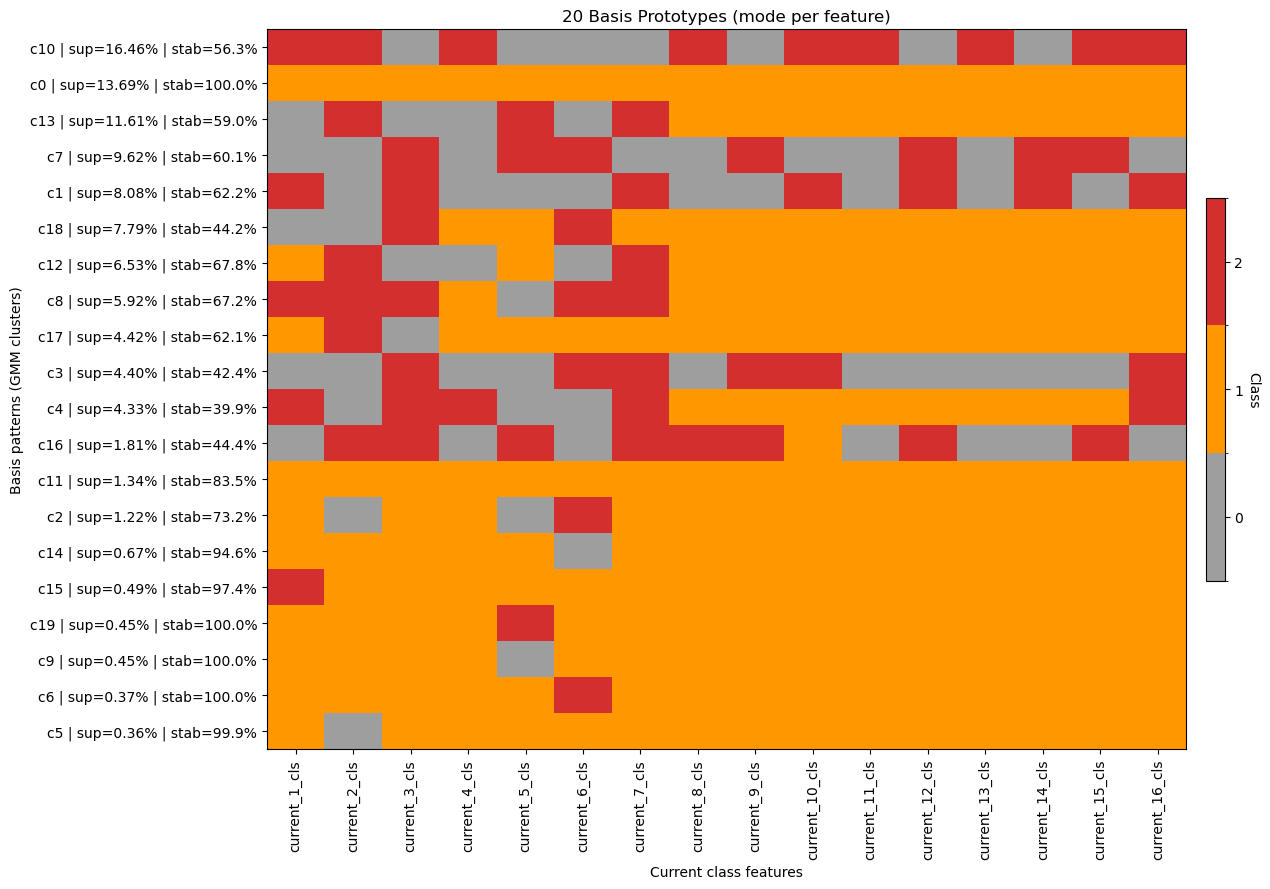

In [48]:
# === Build 20 basis patterns from GMM on your 0.5% subset ===
# Requires: I (original df), idx (indices of the 0.5% subset),
#           labels (shape [len(idx)]), proba (shape [len(idx), 20])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1) attach cluster labels to the subsample
I_sub = I.iloc[idx].copy()
I_sub["cluster"] = labels

# 2) prototype (mode) + stability (% of rows matching the mode) + support (%)
rows = []
for c in np.unique(labels):
    sub = I_sub[I_sub["cluster"] == c]
    sup = 100 * len(sub) / len(I_sub)
    for col in I.columns:
        mv = sub[col].mode()[0]
        stab = sub[col].value_counts(normalize=True).get(mv, 0.0) * 100
        rows.append({"cluster": int(c), "feature": col,
                     "proto_val": int(mv), "stability_%": round(stab, 1),
                     "support_%": round(sup, 2)})

catalog = pd.DataFrame(rows)

# 3) summary per cluster
summary = (catalog.groupby("cluster")["stability_%"].mean()
           .rename("avg_stability_%").to_frame()
           .join(catalog.groupby("cluster")["support_%"].first()))

# 4) pivot to matrix [clusters x features], sort clusters by support desc
feat_order = sorted(I.columns, key=lambda c: int(c.split("_")[1]))
order = summary.sort_values(["support_%","avg_stability_%"], ascending=[False, False]).index.tolist()

proto_mat = (catalog.pivot_table(index="cluster", columns="feature",
                                 values="proto_val", aggfunc="first")
             .reindex(index=order, columns=feat_order))

# 5) optional: export the basis as a compact dict
basis = {int(cid): proto_mat.loc[cid].astype(int).tolist() for cid in proto_mat.index}

# 6) heatmap (rows=basis patterns, cols=currents, color=class 0/1/2)
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0,1,2
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

row_labels = [f"c{int(cid)} | sup={summary.loc[cid,'support_%']:.2f}% | stab={summary.loc[cid,'avg_stability_%']:.1f}%"
              for cid in proto_mat.index]

fig, ax = plt.subplots(figsize=(0.55*proto_mat.shape[1] + 4, 0.35*proto_mat.shape[0] + 2))
im = ax.imshow(proto_mat.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xticks(np.arange(len(feat_order))); ax.set_xticklabels(feat_order, rotation=90)
ax.set_yticks(np.arange(len(row_labels))); ax.set_yticklabels(row_labels)

cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2], fraction=0.02, pad=0.02)
cbar.set_label("Class", rotation=270, labelpad=12)

ax.set_xlabel("Current class features")
ax.set_ylabel("Basis patterns (GMM clusters)")
ax.set_title("20 Basis Prototypes (mode per feature)")

plt.tight_layout()
plt.show()

# 7) save the basis + summaries (so you can reuse without recomputing)
catalog.to_pickle("basis_catalog_gmm20.pkl")
summary.to_pickle("basis_summary_gmm20.pkl")
pd.DataFrame.from_dict(basis, orient="index").to_pickle("basis_vectors_gmm20.pkl")


In [49]:
# 1) Reload your saved GMM + UMAP if needed
# (assuming you still have `gmm` from before and `um_hi` the 10D UMAP)

from scipy import sparse
import pandas as pd

# --- Encode the whole dataframe I ---
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)
X_encoded_full = enc.fit_transform(I)

# --- Reduce with the same SVD ---
svd_full = TruncatedSVD(n_components=40, random_state=42)
X_svd_full = svd_full.fit_transform(X_encoded_full).astype(np.float32)

# --- Transform with the UMAP fitted on subsample ---
X_umap10_full = um_hi.transform(X_svd_full)

# --- Predict with the GMM fitted on subsample ---
labels_full = gmm.predict(X_umap10_full)
proba_full  = gmm.predict_proba(X_umap10_full)

print("Full dataset assigned:", labels_full.shape, proba_full.shape)


/usr/lib/python3/dist-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Full dataset assigned: (1287658,) (1287658, 20)


In [50]:
# Add hard cluster and soft weights
proba_cols = [f"pat_{i}" for i in range(proba_full.shape[1])]
I_with_patterns = pd.concat([
    I.reset_index(drop=True),
    pd.DataFrame(labels_full, columns=["cluster"]),
    pd.DataFrame(proba_full, columns=proba_cols)
], axis=1)

print(I_with_patterns.head())


   current_1_cls  current_2_cls  current_3_cls  current_4_cls  current_5_cls  \
0              1              1              1              1              1   
1              2              2              1              2              2   
2              1              1              0              2              1   
3              1              1              1              0              1   
4              0              0              0              2              2   

   current_6_cls  current_7_cls  current_8_cls  current_9_cls  current_10_cls  \
0              1              1              1              1               1   
1              1              0              1              1               1   
2              0              2              1              1               1   
3              1              1              1              1               1   
4              2              0              2              1               1   

   ...         pat_10         pa

In [52]:
I_with_patterns['cluster'].head()

0     0
1     8
2    12
3    11
4    13
Name: cluster, dtype: int64

In [54]:
I_with_patterns.to_pickle("I_with_patterns.pkl")


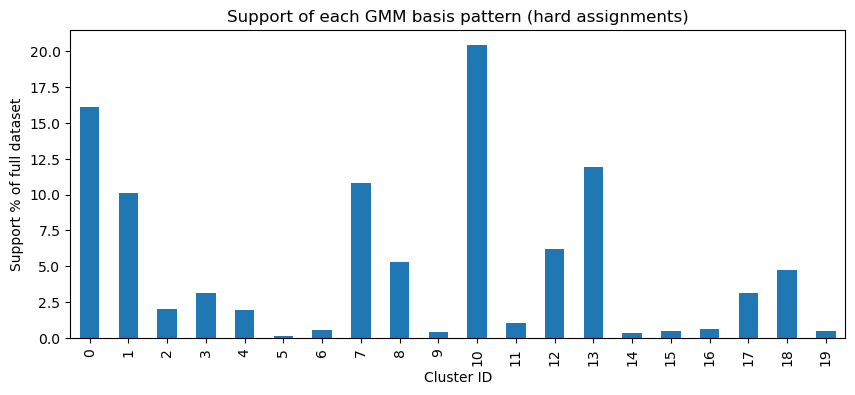

In [55]:
import matplotlib.pyplot as plt

cluster_counts = I_with_patterns["cluster"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10,4))
cluster_counts.plot(kind="bar")
plt.ylabel("Support % of full dataset")
plt.xlabel("Cluster ID")
plt.title("Support of each GMM basis pattern (hard assignments)")
plt.show()


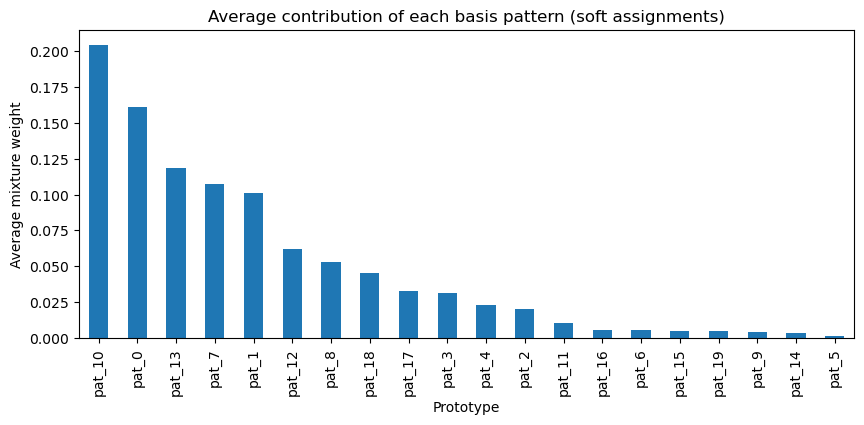

In [56]:
proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]

mean_weights = I_with_patterns[proba_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
mean_weights.plot(kind="bar")
plt.ylabel("Average mixture weight")
plt.xlabel("Prototype")
plt.title("Average contribution of each basis pattern (soft assignments)")
plt.show()


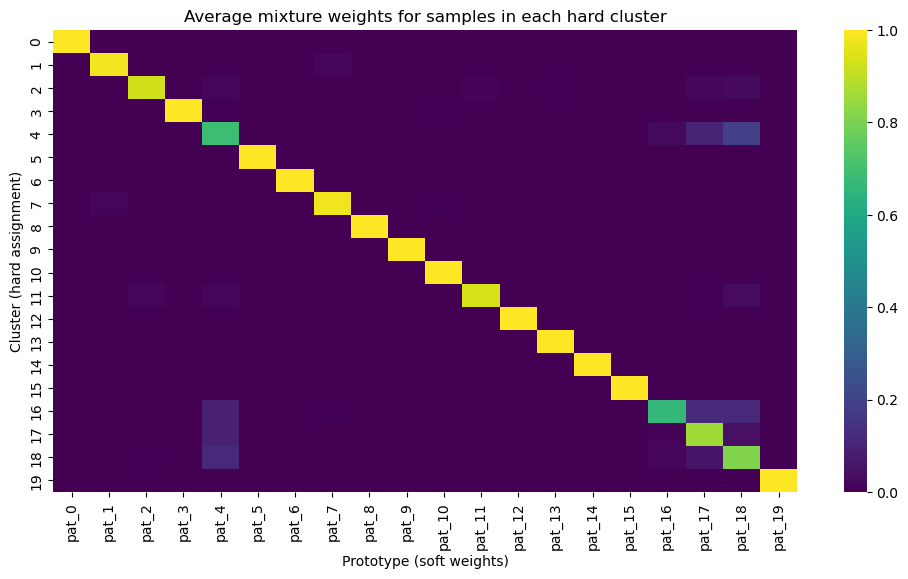

In [57]:
import seaborn as sns

avg_proba_per_cluster = I_with_patterns.groupby("cluster")[proba_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(avg_proba_per_cluster, cmap="viridis", annot=False)
plt.title("Average mixture weights for samples in each hard cluster")
plt.xlabel("Prototype (soft weights)")
plt.ylabel("Cluster (hard assignment)")
plt.show()


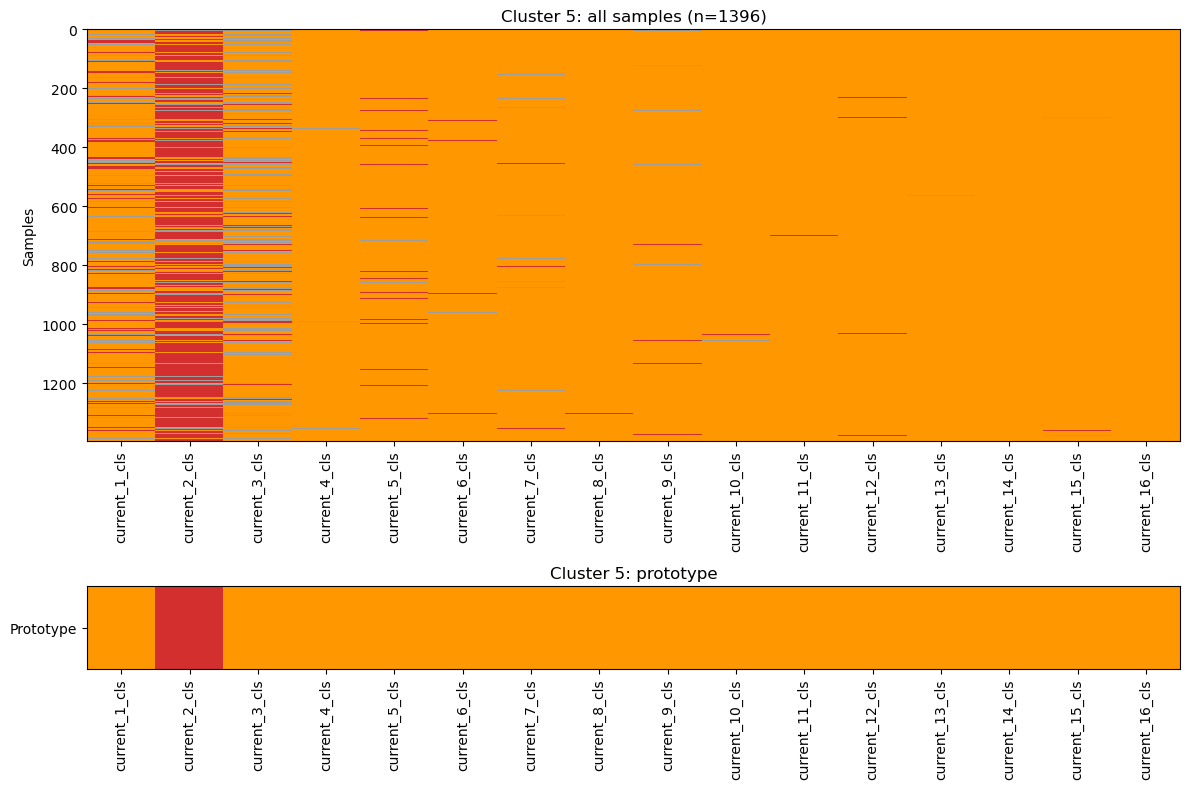

In [65]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

cluster_id = 5   # pick the cluster you want
feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))

# subset rows belonging to that cluster
sub = I_with_patterns[I_with_patterns["cluster"] == cluster_id][feat_order].astype(int)

# prototype row
proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

# --- Plot ---
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0=gray, 1=orange, 2=red
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios":[5,1]})

# (A) all samples in cluster
axes[0].imshow(sub.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[0].set_title(f"Cluster {cluster_id}: all samples (n={len(sub)})")
axes[0].set_xticks(range(len(feat_order)))
axes[0].set_xticklabels(feat_order, rotation=90)
axes[0].set_ylabel("Samples")

# (B) prototype (mode)
axes[1].imshow(proto, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_xticks(range(len(feat_order)))
axes[1].set_xticklabels(feat_order, rotation=90)
axes[1].set_yticks([0]); axes[1].set_yticklabels(["Prototype"])
axes[1].set_title(f"Cluster {cluster_id}: prototype")

plt.tight_layout()
plt.show()


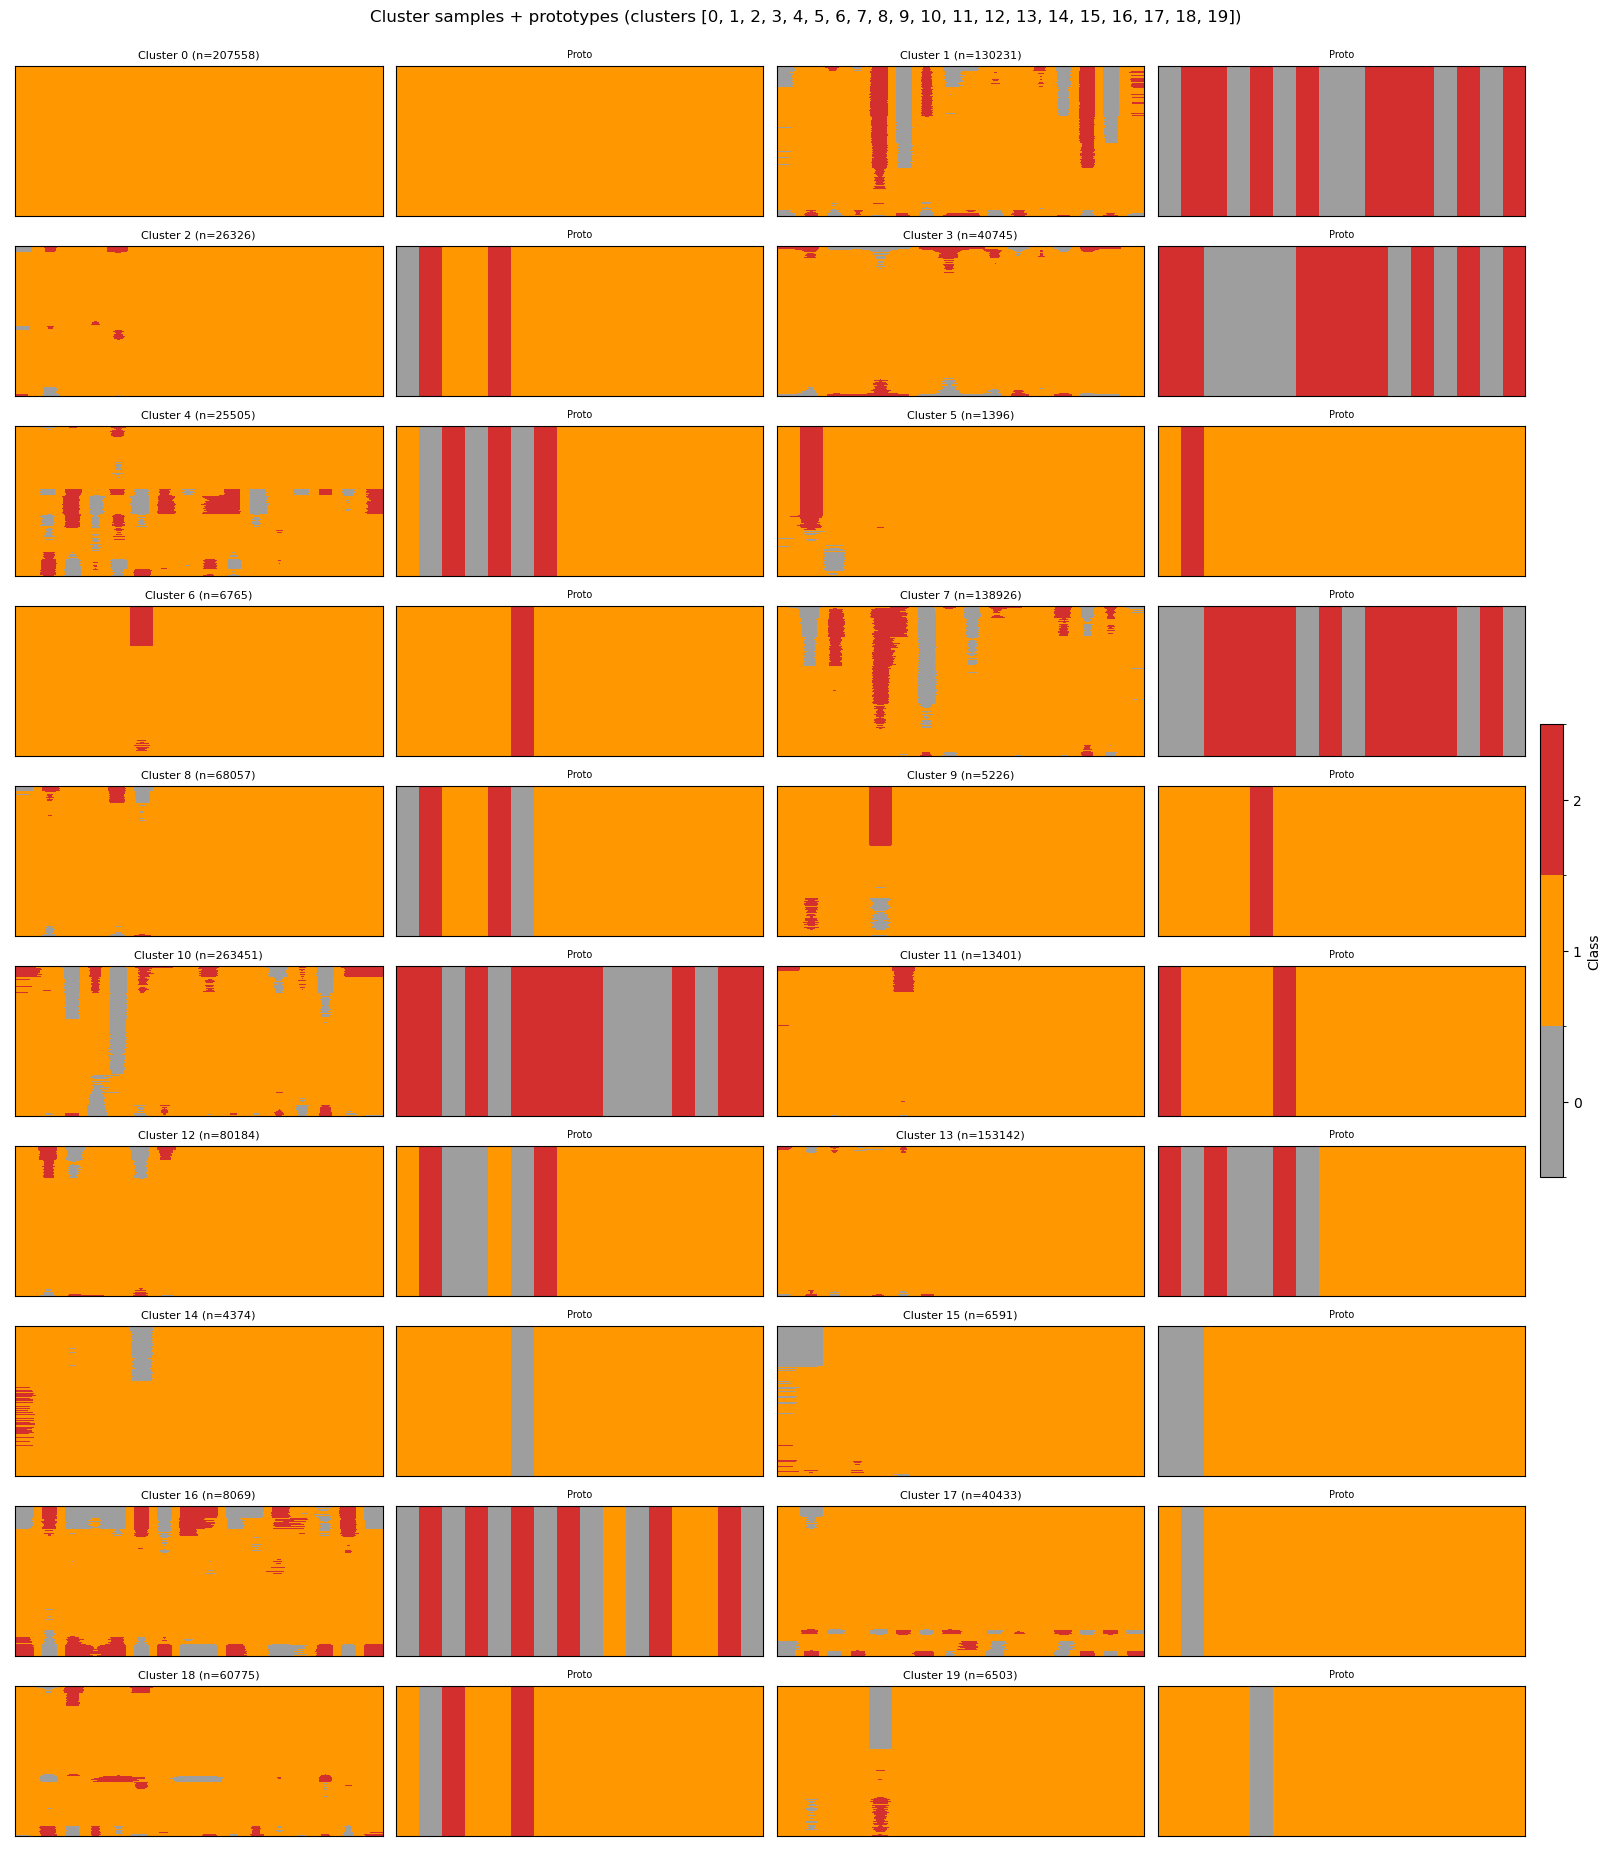

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# config
MAX_ROWS_PER_CLUSTER = 1000000  # cap rows per cluster for readability
GRID_ROWS, GRID_COLS = 5, 4  # 4x4 grid per page
SORT_BY_SIMILARITY = True

feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))
clusters = sorted(I_with_patterns["cluster"].unique())

cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

def hamming(a, b):
    return (a != b).sum(axis=1)

# paginate over clusters
per_page = GRID_ROWS * GRID_COLS
for page_start in range(0, len(clusters), per_page):
    page_clusters = clusters[page_start:page_start+per_page]

    fig, axes = plt.subplots(GRID_ROWS*2, GRID_COLS, figsize=(4*GRID_COLS, 1.8*GRID_ROWS*2),
                             constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for j, cid in enumerate(page_clusters):
        sub = I_with_patterns[I_with_patterns["cluster"] == cid][feat_order].astype(int)
        proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

        # sort by similarity if desired
        if SORT_BY_SIMILARITY:
            d = hamming(sub.values, proto)
            order = np.argsort(d)
            sub = sub.iloc[order]

        # cap rows
        if len(sub) > MAX_ROWS_PER_CLUSTER:
            idx = np.random.choice(len(sub), size=MAX_ROWS_PER_CLUSTER, replace=False)
            sub = sub.iloc[idx]

        # pick positions: row=2*gridrow, row+1=prototype
        grid_pos = j*2
        ax_samples = axes[grid_pos]
        last_im = ax_samples.imshow(sub.values, aspect="auto", cmap=cmap, norm=norm)
        ax_samples.set_title(f"Cluster {cid} (n={len(sub)})", fontsize=8)
        ax_samples.set_xticks([]); ax_samples.set_yticks([])

        ax_proto = axes[grid_pos+1]
        ax_proto.imshow(proto, aspect="auto", cmap=cmap, norm=norm)
        ax_proto.set_xticks([]); ax_proto.set_yticks([])
        ax_proto.set_title("Proto", fontsize=7)

    # hide unused axes
    for ax in axes[len(page_clusters)*2:]:
        ax.axis("off")

    fig.colorbar(last_im, ax=axes, ticks=[0,1,2], fraction=0.015, pad=0.01, label="Class")
    fig.suptitle(f"Cluster samples + prototypes (clusters {page_clusters})", y=1.02)
    plt.show()


In [30]:
Y_soft.head()

,pat_0,pat_1,pat_2,pat_3,pat_4,pat_5,pat_6,pat_7,pat_8,pat_9,pat_10,pat_11,pat_12,pat_13,pat_14,pat_15,pat_16,pat_17,pat_18,pat_19
0,1.0,0.0,1.274793e-17,0.0,5.544864e-28,0.0,0.0,0.0,0.000000e+00,0.0,0.0,6.612444e-24,0.000000e+00,0.0,0.0,0.0,1.252761e-41,2.440567e-18,2.448054e-19,0.0
1,0.0,0.0,5.019338e-09,0.0,5.620128e-15,0.0,0.0,0.0,1.000000e+00,0.0,0.0,7.641373e-26,9.809089e-45,0.0,0.0,0.0,5.953941e-25,5.169662e-12,7.317964e-13,0.0
2,0.0,0.0,2.906027e-06,0.0,1.994967e-11,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,9.999971e-01,0.0,0.0,0.0,1.219233e-19,4.513328e-10,4.724652e-10,0.0
3,0.0,0.0,4.298860e-27,0.0,2.484897e-06,0.0,0.0,0.0,0.000000e+00,0.0,0.0,9.840893e-01,0.000000e+00,0.0,0.0,0.0,2.264839e-11,9.101342e-03,6.806883e-03,0.0
4,0.0,0.0,1.973551e-08,0.0,4.287194e-15,0.0,0.0,0.0,2.649660e-12,0.0,0.0,0.000000e+00,4.256599e-32,1.0,0.0,0.0,2.512135e-25,9.867977e-13,4.400651e-13,0.0


In [76]:
# pick 5 random rows
check_idx = np.random.choice(len(I), size=5, replace=False)

for idx in check_idx:
    print(f"\nRow {idx}")
    print("Original currents:", I.iloc[idx].to_numpy())
    print("Assigned cluster:", I_with_patterns.iloc[idx]["cluster"])
    print("Top-3 mixture weights:", 
          I_with_patterns.iloc[idx][[f"pat_{i}" for i in np.argsort(-I_with_patterns.iloc[idx][proba_cols].values)[:3]]])



Row 198527
Original currents: [0 2 0 2 2 0 0 2 2 0 2 0 0 1 2 0]
Assigned cluster: 1.0
Top-3 mixture weights: pat_1     9.999915e-01
pat_7     8.272699e-06
pat_18    1.012107e-07
Name: 198527, dtype: float64

Row 305627
Original currents: [1 2 0 2 0 2 0 2 1 2 1 1 2 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    9.998802e-01
pat_2     1.198364e-04
pat_17    6.855623e-09
Name: 305627, dtype: float64

Row 941836
Original currents: [2 2 0 2 0 2 2 0 0 0 2 0 2 1 0 2]
Assigned cluster: 10.0
Top-3 mixture weights: pat_10    9.999991e-01
pat_18    5.515275e-07
pat_4     2.854527e-07
Name: 941836, dtype: float64

Row 1187823
Original currents: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Assigned cluster: 0.0
Top-3 mixture weights: pat_0     1.000000e+00
pat_2     2.608512e-18
pat_17    4.880699e-19
Name: 1187823, dtype: float64

Row 684324
Original currents: [2 0 2 2 0 0 2 2 0 2 1 0 1 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    1.000000e+00
pat_2     1.845464e-09
pat_17 

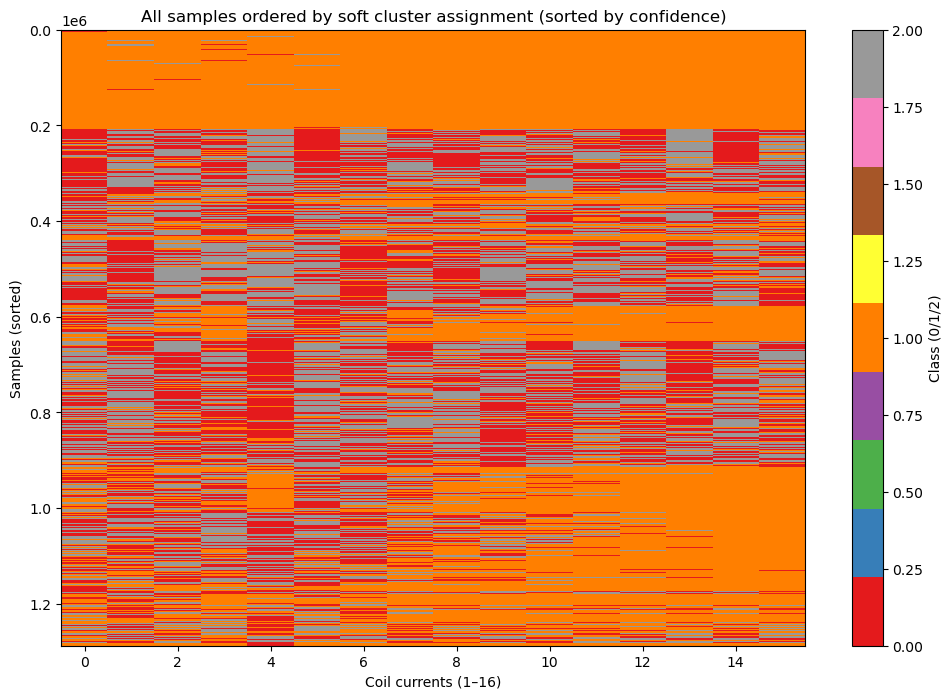

In [75]:
import numpy as np
import matplotlib.pyplot as plt

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
feat_cols  = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda x: int(x.split("_")[1]))
W = I_with_patterns[proba_cols].to_numpy()    # [N, K]
Y = I_with_patterns[feat_cols].to_numpy()     # [N, 16]

# pick top cluster + confidence
top = W.argmax(axis=1)
conf = W.max(axis=1)

# sort samples: first by cluster, then by confidence (so "weak" assignments go to bottom)
order = np.lexsort((1-conf, top))  
Y_sorted = Y[order]
top_sorted = top[order]

# plot big heatmap
plt.figure(figsize=(12,8))
plt.imshow(Y_sorted, aspect="auto", cmap="Set1", interpolation="nearest")
plt.colorbar(label="Class (0/1/2)")
plt.title("All samples ordered by soft cluster assignment (sorted by confidence)")
plt.xlabel("Coil currents (1–16)")
plt.ylabel("Samples (sorted)")
plt.show()


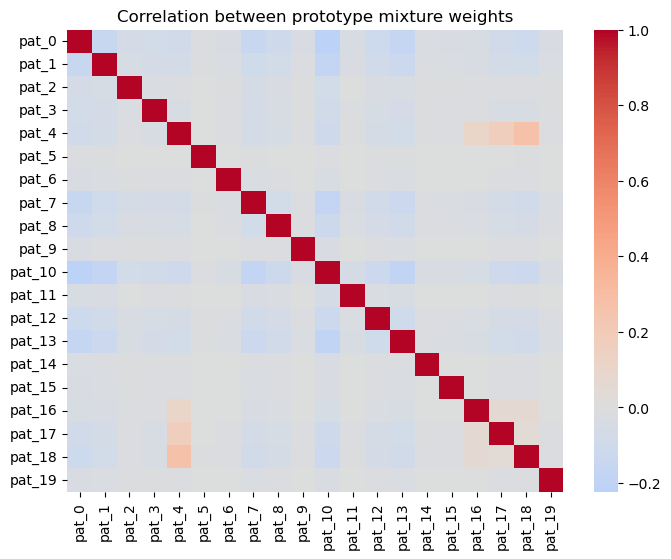

In [58]:
corr = I_with_patterns[proba_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between prototype mixture weights")
plt.show()


In [42]:
import pandas as pd

# wrap the numpy array into a DataFrame with nice col names
X_umap10_df = pd.DataFrame(X_umap10, columns=[f"umap{i+1}" for i in range(X_umap10.shape[1])])

# save to disk (choose your path)
X_umap10_df.to_parquet("X_umap10.parquet", index=False)   # efficient binary format
# or
X_umap10_df.to_csv("X_umap10.csv", index=False)           # plain text, bigger

print("Saved:", X_umap10_df.shape)


ArrowKeyError: A type extension with name pandas.period already defined

In [82]:
import numpy as np

# your coil current columns
feat_cols = [c for c in I_with_patterns.columns if c.startswith("current_")]

# cluster labels
labels = I_with_patterns["cluster"].to_numpy()

# initialize prototype tensor: (clusters × coils × 3 classes)
D = np.zeros((gmm.n_components, len(feat_cols), 3))

for k in range(gmm.n_components):
    rows = I_with_patterns.loc[labels == k, feat_cols]
    if len(rows) == 0:
        continue
    for j, col in enumerate(feat_cols):
        vals = rows[col].values
        for c in [0, 1, 2]:
            D[k, j, c] = np.mean(vals == c)

print("D shape:", D.shape)  # should be (20, 16, 3)


D shape: (20, 16, 3)


In [83]:
import joblib, json, numpy as np, os

save_dir = "/media/alireza-linux/MagLev Simulator and Beyond/ML saved files"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(svd,  os.path.join(save_dir, "svd_model.pkl"))
joblib.dump(um_hi, os.path.join(save_dir, "umap_model.pkl"))
joblib.dump(gmm,  os.path.join(save_dir, "gmm_model.pkl"))

np.save(os.path.join(save_dir, "soft_prototypes.npy"), D)

meta = {"features": feat_cols, "K": D.shape[0], "classes": [0,1,2]}
with open(os.path.join(save_dir, "training_meta.json"), "w") as f:
    json.dump(meta, f)

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
np.savez_compressed(
    os.path.join(save_dir, "assignments_full.npz"),
    labels=I_with_patterns["cluster"].to_numpy(),
    proba=I_with_patterns[proba_cols].to_numpy(dtype=np.float32),
)
